In [1]:
# import all packages
import pandas as pd
import numpy as np
import glob, os
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import math
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm
import geopandas as gpd

### Buildings data

### Surface and Volume from GHSL

In [2]:
# builtarea = ['surface', 'volume']
# reading data from multiple years
def read_Data(path, merged_column_names, builtarea):
    df_merged = pd.DataFrame(columns = ['GEOID'])
    if builtarea == 'surface':
        divideby = 1 # area in sqmeter
    elif builtarea == 'volume':
        divideby = 1 # volume in m^3
    else:
        print('Check input format')
        
    merged_column_names.append(builtarea)
    # print(merged_column_names)
    os.chdir(path)
    for file in glob.glob("*.csv"):
        df = pd.read_csv(file, dtype={'GEOID':str})
        df['TOTALAREA_SQKM'] = df[['ALAND', 'AWATER']].sum(axis=1)/1000000
        df[builtarea] = df['sum']/divideby
        df = df.sort_values(by='GEOID').reset_index(drop=True)
        # print(df.columns)
        print('Shape of the dataframe:', df.shape, 'and Total built area (volume) in squaremeters (m^3): ', df[builtarea].sum())
        df_merged = df_merged.merge(df, on='GEOID', suffixes = ('', file[16:-4]), how = 'outer')

    return df_merged

In [3]:
surface_path = r'D:\Work\Box Sync\Quantify Infrastructure\GHSL_AREA_VOL_data\Surface\\'
volume_path = r'D:\Work\Box Sync\Quantify Infrastructure\GHSL_AREA_VOL_data\Volume\\'

column_names = ['GEOID', 'NAMELSAD', 'sum']

df_surface = read_Data(surface_path, column_names, 'surface')
df_volume = read_Data(volume_path, column_names, 'volume')

Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  21644923940.827446
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  24308169725.54902
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  27090809701.21176
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  30132932830.333332
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  34211558949.564705
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  36204795388.78432
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  37375579106.32157
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  157313248400.5608
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  173143434872.09802
Shape of the dataframe: (32188, 8

In [4]:
# df_volume.filter(regex=("volume*")).columns # '1714000'
# 168.465656 - 121.339918
# df_volume[['GEOID', 'NAMELSAD', 'volume', 'volume_1990', 'volume_1995', 'volume_2000', 'volume_2010', 'volume_2015', 'volume_2020']]

In [5]:
# To check the consecuate changes in area/ volumne in each 10 yr interval
df_surface['change_80_90'] = (df_surface['surface_1990'] - df_surface['surface'])
df_surface['change_90_00'] = (df_surface['surface_2000'] - df_surface['surface_1990'])
df_surface['change_00_10'] = (df_surface['surface_2010'] - df_surface['surface_2000'])
df_surface['change_10_20'] = (df_surface['surface_2020'] - df_surface['surface_2010'])

df_volume['Vchange_80_90'] = (df_volume['volume_1990'] - df_volume['volume'])
df_volume['Vchange_90_00'] = (df_volume['volume_2000'] - df_volume['volume_1990'])
df_volume['Vchange_00_10'] = (df_volume['volume_2010'] - df_volume['volume_2000'])
df_volume['Vchange_10_20'] = (df_volume['volume_2020'] - df_volume['volume_2010'])

### Non residential buildings data from GHSL for the year 2020

In [6]:
df_non_res_S = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\GHSL_AREA_VOL_data\Non_res_surface\BuiltArea_GHSL_S_nres_2020.csv')
df_non_res_S['GEOID'] = df_non_res_S['GEOID'].astype(str).str.rjust(7, '0')
df_non_res_S.rename(columns = {'sum':'surface_nonRes_2020'}, inplace= True)
df_non_res_S.columns
df_non_res_V = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\GHSL_AREA_VOL_data\Non_res_surface\BuiltArea_GHSL_V_nres_2020.csv')
df_non_res_V['GEOID'] = df_non_res_V['GEOID'].astype(str).str.rjust(7, '0')
df_non_res_V.rename(columns = {'sum':'volume_nonRes_2020'}, inplace= True)
df_non_res_V.columns

Index(['STATEFP', 'GEOID', 'NAMELSAD', 'ALAND', 'AWATER',
       'volume_nonRes_2020'],
      dtype='object')

### Merge built are with nonResidential: Find residential only

In [7]:
# Merge surface with volume and non residential
# Here surface refers to total building are: res + non-res
df = df_volume.merge(df_surface[['GEOID','surface', 'surface_1990', 'surface_1995', 'surface_2000', 'surface_2010', 'surface_2015', 'surface_2020',
                                 'change_80_90', 'change_90_00', 'change_00_10', 'change_10_20']], on = 'GEOID')
df = df.merge(df_non_res_S[['GEOID', 'surface_nonRes_2020']], on ='GEOID')
df = df.merge(df_non_res_V[['GEOID', 'volume_nonRes_2020']], on ='GEOID')
df['surface_Res_2020'] = df['surface_2020'] - df['surface_nonRes_2020']
df['volume_Res_2020'] = df['volume_2020'] - df['volume_nonRes_2020']

# Residential height in meter
df['height_building'] = df['volume_2020'] / df['surface_2020']
df['floors'] = df['height_building']// 3.048

## Save the clean data to avoid the merging and combining again and again

# df_selected = df[['GEOID', 'TOTALAREA_SQKM_2020', 'surface', 'surface_1990', 'surface_1995', 'surface_2000', 'surface_2010', 'surface_2015', 'surface_2020',
#                    'surface_nonRes_2020','surface_Res_2020', 'volume', 'volume_1990', 'volume_1995', 'volume_2000', 'volume_2010', 'volume_2015', 'volume_2020', 'volume_nonRes_2020',
#                    'Vchange_80_90', 'Vchange_90_00', 'Vchange_00_10', 'Vchange_10_20', 'change_80_90', 'change_90_00', 'change_00_10', 'change_10_20']]

# df_selected.to_csv(r'D:\Work\Box Sync\Quantify Infrastructure\GHSL_AREA_VOL_data\area_vol_clean\GHSL_AREA_VOL_cleaned.csv')

In [8]:
df[['NAMELSAD','surface_2020', 'volume_2020','surface_nonRes_2020','surface_Res_2020','volume_nonRes_2020', 'volume_Res_2020']].describe()/1000

,surface_2020,volume_2020,surface_nonRes_2020,surface_Res_2020,volume_nonRes_2020,volume_Res_2020
count,32.188000,3.218800e+01,32.188000,32.188000,32.188000,3.218800e+01
mean,1161.165003,7.801103e+03,167.222297,993.942705,1415.702965,6.385400e+03
std,5407.612948,4.723404e+04,1004.410381,4457.359925,10144.140057,3.765335e+04
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,77.677229,2.041917e+02,0.000000,74.532750,0.000000,1.967935e+02
50%,222.437198,7.008990e+02,6.718000,209.095184,20.547347,6.494306e+02
75%,740.101875,3.436813e+03,60.105079,663.202121,319.110929,2.991041e+03
max,331180.621741,3.428746e+06,68106.108655,276088.304039,668324.365039,2.760422e+06


In [9]:
df[df['volume_2020']/df['surface_2020'] >= 3][['NAMELSAD','surface_2020', 'volume_2020','surface_nonRes_2020','surface_Res_2020']].sort_values(by = 'surface_2020')

,NAMELSAD,surface_2020,volume_2020,surface_nonRes_2020,surface_Res_2020
918,Tolsona CDP,2.000000e+00,6.000000e+00,0.000000e+00,2.000000e+00
8446,River Forest town,4.309612e+03,2.168891e+04,0.000000e+00,4.309612e+03
27992,Santa Cruz CDP,7.516384e+03,3.173614e+04,3.150706e+02,7.201314e+03
32165,Villa de Sabana comunidad,8.198067e+03,5.068002e+04,0.000000e+00,8.198067e+03
8376,North Crows Nest town,8.229643e+03,5.842759e+04,0.000000e+00,8.229643e+03
...,...,...,...,...,...
27958,San Antonio city,1.840882e+08,1.296802e+09,3.058379e+07,1.535045e+08
18854,New York city,2.125018e+08,2.713595e+09,2.421353e+07,1.882883e+08
1226,Phoenix city,2.422298e+08,1.983561e+09,3.930931e+07,2.029205e+08
27207,Houston city,2.811221e+08,2.278736e+09,6.810611e+07,2.130160e+08


In [10]:
print("Number of missing values in built area data: ===")
df.isna().sum().sum()

Number of missing values in built area data: ===


132

### Read places geometry from shapefile

In [11]:
os.environ['USE_PYGEOS'] = '0'
# Import places map
places_US = gpd.read_file(r'D:\Work\Box Sync\Quantify Infrastructure\MapData\all_places\compiled.shp')
print('Total no of places in the US:===')
print(places_US.shape)

# Exclude states that do not have consistent data for roadways
places_50_states = places_US[(places_US['STATEFP'] != '02') & (places_US['STATEFP'] != '60') & (places_US['STATEFP'] != '66') & (places_US['STATEFP'] != '69') & (places_US['STATEFP'] != '72') & (places_US['STATEFP'] != '78')]
print('No of places in the 50 states:===')
print(places_50_states.shape)

Total no of places in the US:===
(32188, 17)
No of places in the 50 states:===
(31262, 17)


### Join surface volume with geometry

In [12]:
df_with_geom = places_50_states.merge(df[['GEOID', 'surface_2020','surface_Res_2020', 'surface_nonRes_2020', 'volume_2020', 'volume_nonRes_2020', 'volume_Res_2020',
                                          'height_building', 'floors']], on = 'GEOID')
df_with_geom.columns
df_with_geom = df_with_geom.to_crs('EPSG:9311')
print(df.shape, df_with_geom.shape)

(32188, 71) (31262, 25)


In [13]:
# # PLOT THE ATTRIBUTES
# fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14.27,5.27))
# for ax in axes.flatten():
#     continental_ax = ax          
#     # Set bounds to fit desired areas in each plot for epsg 9311
#     continental_ax.set_xlim(-2257388.37, 2695859.75)
#     continental_ax.set_ylim(-2546944.04, 808080.9)
#     df_with_geom.plot(column = 'change_10_20', 
#              ax=continental_ax,
#              legend = True)

In [14]:
# Area of the place in sqkm
df_with_geom['landAreaSqkm'] = df_with_geom['ALAND']/1000000
# Percent of total area that has buildings
df_with_geom['percent_built_surface'] = df_with_geom['surface_2020'] * 100/df_with_geom['ALAND']

df_with_geom.isna().sum().sum()

6

### Add housing units and age from ACS

In [15]:
df_YearBuilt = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\Housing Data ACS\HousingDataCleaned.csv', index_col = 0)
df_YearBuilt['GEOID'] = df_YearBuilt['GEOID'].str[9:]

In [16]:
df_YearBuilt[['GEOID','complete_plumbing', 'Year_Built']]

,GEOID,complete_plumbing,Year_Built
0,0100100,100.0,YB_1960_1979
1,0100124,100.0,YB_1960_1979
2,0100460,100.0,YB_1960_1979
3,0100484,100.0,YB_1980_1999
4,0100676,100.0,YB_1980_1999
...,...,...,...
31904,7287638,100.0,YB_1960_1979
31905,7287863,99.1,YB_1960_1979
31906,7288035,98.7,YB_1960_1979
31907,7288121,100.0,YB_1980_1999


In [17]:
# df_buildings[df_buildings['weighted_avg_age'] <20][['STATEFP', 'NAMELSAD','HUs_occupied','YB_2010_2019', 'YB_2000_2009', 'Year_Built', 'Percent_Built', 'weighted_avg_age']]

In [18]:
df_YearBuilt[df_YearBuilt['GEOID'] == '0652582'][['GEOID', ' !!Total:', 'HUs_occupied', 'HUs_vaccant', 'NAME', 'complete_plumbing', 'Year_Built', 'Percent_Built']]

,GEOID,!!Total:,HUs_occupied,HUs_vaccant,NAME,complete_plumbing,Year_Built,Percent_Built
3061,0652582,21271,20564,707,"Novato city, California",99.6,YB_1960_1979,45.7


In [19]:
df_YearBuilt_selected = df_YearBuilt[['GEOID', ' !!Total:', 'HUs_occupied', 'HUs_vaccant', 'NAME', 'HUs_Total', 'YB_>=_2020', 'YB_2010_2019', 'YB_2000_2009',
               'YB_1980_1999', 'YB_1960_1979', 'YB_1940_1959', 'YB_<=_1939','Year_Built', 'Percent_Built']]

In [20]:
df_YearBuilt.columns

Index(['GEOID', ' !!Total:', 'HUs_occupied', 'HUs_vaccant', 'NAME',
       'HUs_Total', 'YB_>=_2020', 'YB_2010_2019', 'YB_2000_2009',
       'YB_1980_1999', 'YB_1960_1979', 'YB_1940_1959', 'YB_<=_1939',
       'STRUC_detached_1', 'STRUC_attached_1', 'STRUC_apt_2', 'STRUC_apt_3_4',
       'STRUC_apt_5_9', 'STRUC_apt_10_more', 'STRUC_mobile_or_other',
       'HF_Utility_gas', 'HF_Bottled_tank_or_LP gas', 'HF_Electricity',
       'HF_Fueloil_kerosene', 'HF_Coal_coke', 'HF_Others', 'HF_NoFuel',
       'complete_plumbing', 'Year_Built', 'Percent_Built'],
      dtype='object')

### Merge with surface-volume with HUs and age

In [21]:
df_buildings = df_with_geom.merge(df_YearBuilt_selected, on = 'GEOID')
# df_buildings.columns

In [22]:
# get an weighted age for each place 
df_buildings['weighted_avg_age'] = ((2024-1939)*df_buildings['YB_<=_1939'] + (2024-1950)*df_buildings['YB_1940_1959'] + (2024-1970)*df_buildings['YB_1960_1979'] +
                                  (2024-1990)*df_buildings['YB_1980_1999'] + (2024-2004)*df_buildings['YB_2000_2009'] + (2024-2014)*df_buildings['YB_2010_2019'] + 
                                  (2024-2022)*df_buildings['YB_>=_2020'])/100

df_buildings[['STATEFP', 'NAMELSAD','YB_>=_2020','YB_2010_2019', 'YB_2000_2009', 'Year_Built', 'Percent_Built', 'weighted_avg_age']].isna().sum()

STATEFP               0
NAMELSAD              0
YB_>=_2020          489
YB_2010_2019        489
YB_2000_2009        489
Year_Built          489
Percent_Built       489
weighted_avg_age    489
dtype: int64

### Import population and attributes data from depopulation study

In [23]:
df_population = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\forecasted_trend.csv', index_col  = 0)
df_population['GEOID'] = df_population['GEOID'].astype(str).str.rjust(7,'0')

df_attributes = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\df_attributes.csv', index_col  = 0)
df_attributes['GEOID'] = df_attributes['GEOID'].astype(str).str.rjust(7,'0')

df_pop_attr = df_population.merge(df_attributes[['GEOID', 'REGION', 'city type', 'weighted_HU_density_sqmi',
                                                 'ua-to-place allocation factor_max', 'population_ua_min',
                                                 'population_ua_max', 'median_income']], on = 'GEOID')

In [24]:
df_attributes.shape, df_population.shape

((31908, 33), (31617, 58))

In [25]:
df_attributes.columns

Index(['STATEFP', 'GEOID', 'NAMELSAD', 'weighted_HU_density_sqmi', 'label',
       'density_km2', 'CensusPop_20', 'future trend from SSP 1',
       'future trend from SSP 2', 'future trend from SSP 3',
       'future trend from SSP 4', 'future trend from SSP 5', 'REGION',
       'DIVISION', 'tt_2_work_place', 'no_veh', 'veh_1', 'veh_2_or+',
       'GEOID_place', 'GEOID_cbsa', 'cbsa20-to-place allocation factor',
       'tt_2_work', 'GEOID_', 'Urban area (2022)_count',
       'population_place_sum', 'ua-to-place allocation factor_min',
       'ua-to-place allocation factor_max', 'population_ua_min',
       'population_ua_max', 'city type', 'median_income', 'veh 1+',
       'veh_<=_1'],
      dtype='object')

In [26]:
df_population[(df_population['ssp42020'] -df_population['CensusPop_20']) > 0][['NAMELSAD', 'CensusPop_20','ssp22020', 'ssp22030', 'ssp22040', 
                                                                               'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']]

,NAMELSAD,CensusPop_20,ssp22020,ssp22030,ssp22040,ssp22050,ssp22060,ssp22070,ssp22080,ssp22090,ssp22100
89,West Blocton town,1217,1225.018133,1171.142351,1106.233408,1039.292918,979.340961,928.365265,878.364895,836.323534,813.242878
103,Coffee Springs town,206,208.023567,205.311713,198.584845,189.825234,180.106608,170.365040,157.668422,145.820692,132.991004
123,Oak Hill town,14,14.982006,13.076625,12.118604,10.186573,9.199236,8.206570,7.208573,7.144612,6.135955
330,Haleburg town,112,113.013370,112.114153,108.247648,104.289976,100.346082,97.371079,93.364991,89.330720,84.303547
482,Chunchula CDP,195,197.009336,195.092797,189.169319,181.231705,173.293557,165.347943,154.397925,144.415775,134.420293
...,...,...,...,...,...,...,...,...,...,...,...
31016,Steuben village,122,123.016960,117.143314,109.266512,102.308442,97.350560,92.361022,87.369705,81.362021,76.306206
31402,Waukau CDP,302,305.010415,313.972637,318.907328,319.833751,321.753213,323.666253,323.565127,318.478747,309.408176
31408,Wiota CDP,71,72.009070,69.067762,64.115024,60.132432,56.147155,51.170257,46.170541,42.147682,37.131860
31583,Owl Creek CDP,4,4.953087,5.181235,5.181235,4.953087,4.953087,4.953087,4.953087,4.953087,4.953087


In [27]:
df_population[['ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080', 'ssp22090','ssp22100', 'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060','ssp12070', 
                'ssp12080', 'ssp12090', 'ssp12100', 'ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060','ssp42070', 'ssp42080', 'ssp42090', 
                'ssp42100']] =df_population[['ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080', 'ssp22090','ssp22100', 'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 
                'ssp12060','ssp12070','ssp12080', 'ssp12090', 'ssp12100', 'ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060', 'ssp42070', 'ssp42080', 'ssp42090', 'ssp42100']].round(0)

In [28]:
# Total population for SSP 2 for each 10 yr interval
print('Total population in millions for 51 states: ===')
df_population[['CensusPop_20','ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum() / 1000000

Total population in millions for 51 states: ===


CensusPop_20    249.755152
ssp22020        250.994894
ssp22030        271.282461
ssp22040        289.394468
ssp22050        305.168689
ssp22060        320.539042
ssp22070        334.443090
ssp22080        344.689154
ssp22090        350.775271
ssp22100        353.489975
dtype: float64

### Merge buildings with population

In [29]:
building_with_pop_all = df_buildings.merge(df_pop_attr[['GEOID', 'State', 'REGION', 'ua-to-place allocation factor_max', 'population_ua_min',
                                                    'population_ua_max','label', 'future trend from SSP 2', 'CensusPop_20', 'city type','weighted_HU_density_sqmi','median_income',
                                                   'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080',
                                                   'ssp22090','ssp22100', 'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060','ssp12070', 
                                                   'ssp12080', 'ssp12090', 'ssp12100', 'ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060',
                                                   'ssp42070', 'ssp42080', 'ssp42090', 'ssp42100']], on = 'GEOID', how='left')

In [30]:
building_with_pop_all[building_with_pop_all['GEOID'].str.startswith('214800')][['GEOID', 'NAMELSAD','CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050']]
# 2010 Census
# Louisville/Jefferson County metro government (balance), Kentucky	597337
# 2020 Census
# Louisville city, Kentucky	246161
# Louisville/Jefferson County metro government (balance), Kentucky	386884

# 246161+386884 = 633045

,GEOID,NAMELSAD,CensusPop_20,ssp22020,ssp22030,ssp22040,ssp22050
10251,2148006,Louisville/Jefferson County metro government (...,386884.0,389068.4372,424417.2341,456660.9352,485264.1312
10411,2148000,Louisville city,NaN,NaN,NaN,NaN,NaN


In [31]:
building_with_pop_all.shape, df_buildings.shape, df_population.shape, df_attributes.shape

((31262, 80), (31262, 42), (31617, 58), (31908, 33))

In [32]:
building_with_pop_all[['CensusPop_20','ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080','ssp22090','ssp22100', 
                       'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060','ssp12070', 'ssp12080', 'ssp12090', 'ssp12100','ssp42020', 
                       'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060','ssp42070', 'ssp42080', 'ssp42090', 'ssp42100']].isna().sum().sum()

1189

In [33]:
building_with_pop_all['percentchangeinpop'] = np.abs((building_with_pop_all['ssp42020'] - building_with_pop_all['CensusPop_20'])/building_with_pop_all['CensusPop_20'])

In [34]:
print("Shape of building dataframe", building_with_pop_all.shape[0])
print("No of places within 1% variation in 2020 census population and ssp scenario 2 and 4")
print("ssp2", building_with_pop_all[np.abs((building_with_pop_all['ssp22020'] - building_with_pop_all['CensusPop_20'])/building_with_pop_all['CensusPop_20']) < 0.01].shape[0])
print("ssp4", building_with_pop_all[np.abs((building_with_pop_all['ssp42020'] - building_with_pop_all['CensusPop_20'])/building_with_pop_all['CensusPop_20']) < 0.01].shape[0])
print("No of places over 1% variation in 2020 census population and ssp scenario 2 and 4")
print("ssp2", building_with_pop_all[np.abs((building_with_pop_all['ssp22020'] - building_with_pop_all['CensusPop_20'])/building_with_pop_all['CensusPop_20']) >= 0.01].shape[0])
print("ssp4", building_with_pop_all[np.abs((building_with_pop_all['ssp42020'] - building_with_pop_all['CensusPop_20'])/building_with_pop_all['CensusPop_20']) >= 0.01].shape[0])
print("No of places over 5% variation in 2020 census population and ssp scenario 2 and 4")
print("ssp2", building_with_pop_all[np.abs((building_with_pop_all['ssp22020'] - building_with_pop_all['CensusPop_20'])/building_with_pop_all['CensusPop_20']) >= 0.05].shape[0])
print("ssp4", building_with_pop_all[np.abs((building_with_pop_all['ssp42020'] - building_with_pop_all['CensusPop_20'])/building_with_pop_all['CensusPop_20']) >= 0.05].shape[0])

Shape of building dataframe 31262
No of places within 1% variation in 2020 census population and ssp scenario 2 and 4
ssp2 29208
ssp4 30581
No of places over 1% variation in 2020 census population and ssp scenario 2 and 4
ssp2 2010
ssp4 637
No of places over 5% variation in 2020 census population and ssp scenario 2 and 4
ssp2 187
ssp4 176


In [35]:
# excluding cities that varies over 10% in population forecast in 2020 for ssp4
building_with_pop = building_with_pop_all[(building_with_pop_all['percentchangeinpop'] <=.01)]

In [36]:
# building_with_pop[building_with_pop['city type'] == 'not enough data'].head() #shape[0] # ['CensusPop_20'].sum()

In [37]:
building_with_pop.groupby('city type')[['Percent_Built','weighted_HU_density_sqmi']].describe()

Percent_Built                                              \
                        count       mean        std   min     25%     50%   
city type                                                                   
not enough data           8.0  89.600000  19.413397  53.8  90.750  100.00   
periurban              5683.0  42.755780  13.207129  19.3  33.400   39.90   
rural                 17395.0  46.312785  16.434045  19.2  34.700   42.10   
suburban               6857.0  41.337553  12.070528  18.4  32.600   39.00   
urban                   312.0  42.549679  11.208974  20.8  34.775   41.05   

                                weighted_HU_density_sqmi               \
                     75%    max                    count         mean   
city type                                                               
not enough data  100.000  100.0                      0.0          NaN   
periurban         48.900  100.0                   5700.0   560.814497   
rural             53.300  100.0                  17647.0    33.664466   
suburban          47.500  100.0                   6885.0   953.106510   
urban             48.725   90.7                    312.0  6216.890065   

                                                                     \
                         std          min          25%          50%   
city type                                                             
not enough data          NaN          NaN          NaN          NaN   
periurban         691.968261     0.150793   103.031628   278.353508   
rural             106.229703     0.033770     5.570616    14.014080   
suburban          862.292303     0.000000   261.412868   720.320844   
urban            3912.153516  3018.272827  4259.693215  4958.075743   

                                            
                         75%           max  
city type                                   
not enough data          NaN           NaN  
periurban         746.844116   5904.184022  
rural              32.648646   5369.562100  
suburban         1419.115506  10742.379990  
urban            6775.948549  30707.800203

In [38]:
building_with_pop['weighted_HU_density_sqmi'].isna().sum()

37

In [39]:
condition = building_with_pop[' !!Total:'] != 0
building_with_pop.loc[condition,'HU_density_sqmile'] = building_with_pop[' !!Total:'] / (3.86102e-7 * building_with_pop['ALAND'])
building_with_pop.loc[condition,'avg_HU_size_Res_sqm'] = (building_with_pop['volume_Res_2020'] / building_with_pop[' !!Total:']) # measures avg res unit volume

c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [40]:
building_with_pop[['weighted_HU_density_sqmi','HU_density_sqmile','avg_HU_size_Res_sqm']].describe()

,weighted_HU_density_sqmi,HU_density_sqmile,avg_HU_size_Res_sqm
count,30544.000000,30544.000000,30544.000000
mean,402.453100,560.988290,2013.710058
std,957.209693,855.619435,5430.406602
min,0.000000,0.113780,29.581684
25%,10.849760,139.421515,1275.605437
50%,42.721781,340.212967,1668.793796
75%,361.056782,671.694823,2169.058984
max,30707.800203,60328.412114,344299.263434


In [41]:
# building_with_pop[building_with_pop['avg_HU_size_sqm'] >10000][['STATEFP', 'NAMELSAD', 'avg_HU_size_sqm','surface_Res_2020', 'surface_nonRes_2020', 'volume_2020',]]

In [42]:
print(building_with_pop.shape)

(30581, 83)


In [43]:
print('Total NaNs in population and built area:===')
print(building_with_pop[['CensusPop_20', 'ssp22040', 'surface_Res_2020']].isna().sum())
print("Places with no built area:===", building_with_pop[building_with_pop['surface_Res_2020'] == 0].shape[0])
print("Places with zero population in census 2020:===", building_with_pop[building_with_pop['CensusPop_20'] == 0].shape[0])
print("Places with no available population forecast:===", building_with_pop[building_with_pop['ssp22040'].isnull()].shape[0])

Total NaNs in population and built area:===
CensusPop_20        0
ssp22040            0
surface_Res_2020    0
dtype: int64
Places with no built area:=== 0
Places with zero population in census 2020:=== 0
Places with no available population forecast:=== 0


In [44]:
df_YearBuilt[df_YearBuilt['complete_plumbing'] < 50][['GEOID', ' !!Total:', 'HUs_occupied', 'HUs_vaccant', 'NAME', 'complete_plumbing', 'Year_Built', 'Percent_Built']].sort_values(by ='GEOID').tail(20)

,GEOID,!!Total:,HUs_occupied,HUs_vaccant,NAME,complete_plumbing,Year_Built,Percent_Built
944,0285610,42,1,41,"Wiseman CDP, Alaska",0.0,YB_<=_1939,100.0
978,0405970,40,31,9,"Beyerville CDP, Arizona",40.9,YB_1960_1979,100.0
1014,0412150,16,13,3,"Charco CDP, Arizona",27.3,YB_1980_1999,100.0
1044,0416830,27,22,5,"Cowlic CDP, Arizona",0.0,YB_1960_1979,100.0
1150,0438950,16,15,1,"Ko Vaya CDP, Arizona",0.0,YB_1980_1999,100.0
2528,0623630,90,89,1,"Farmington CDP, California",37.3,YB_<=_1939,62.7
3694,0807571,27,14,13,"Bonanza town, Colorado",25.0,YB_1940_1959,100.0
6428,1675970,45,15,30,"Spencer city, Idaho",42.1,YB_2000_2009,63.2
7997,1809352,55,48,7,"Burns City CDP, Indiana",41.7,YB_<=_1939,100.0
9886,2025900,22,22,0,"Garland CDP, Kansas",25.0,YB_2000_2009,75.0


In [45]:
building_with_pop.columns

Index(['STATEFP', 'PLACEFP', 'PLACENS', 'GEOID', 'NAME_x', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'PCICBSA', 'PCINECTA', 'MTFCC', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry', 'surface_2020',
       'surface_Res_2020', 'surface_nonRes_2020', 'volume_2020',
       'volume_nonRes_2020', 'volume_Res_2020', 'height_building', 'floors',
       'landAreaSqkm', 'percent_built_surface', ' !!Total:', 'HUs_occupied',
       'HUs_vaccant', 'NAME_y', 'HUs_Total', 'YB_>=_2020', 'YB_2010_2019',
       'YB_2000_2009', 'YB_1980_1999', 'YB_1960_1979', 'YB_1940_1959',
       'YB_<=_1939', 'Year_Built', 'Percent_Built', 'weighted_avg_age',
       'State', 'REGION', 'ua-to-place allocation factor_max',
       'population_ua_min', 'population_ua_max', 'label',
       'future trend from SSP 2', 'CensusPop_20', 'city type',
       'weighted_HU_density_sqmi', 'median_income', 'ssp22020', 'ssp22030',
       'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090',
     

In [46]:
building_with_pop['per_cap__nonRes_mass_at_2020'] =  building_with_pop['volume_nonRes_2020'] / building_with_pop['CensusPop_20']
building_with_pop['per_cap__total_mass_at_2020'] =  building_with_pop['volume_2020'] / building_with_pop['CensusPop_20']
building_with_pop['per_cap_mass_at_2020'] =  building_with_pop['volume_Res_2020'] / building_with_pop['CensusPop_20']
# building_with_pop['avg_HU_size_sqm_Res'] = building_with_pop['surface_Res_2020'] / building_with_pop['HUs_Total']
stocks_with_pop = building_with_pop[building_with_pop['CensusPop_20'] != 0]
stocks_with_pop = stocks_with_pop[stocks_with_pop['city type'] == 'suburban']
print(stocks_with_pop.shape)

(6885, 86)


c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [47]:
building_with_pop[['GEOID', 'NAMELSAD','HU_density_sqmile', 'avg_HU_size_Res_sqm', 'per_cap__nonRes_mass_at_2020',
        'per_cap_mass_at_2020', 'surface_Res_2020', 'surface_nonRes_2020']].sort_values(by='per_cap_mass_at_2020')

,GEOID,NAMELSAD,HU_density_sqmile,avg_HU_size_Res_sqm,per_cap__nonRes_mass_at_2020,per_cap_mass_at_2020,surface_Res_2020,surface_nonRes_2020
5859,1579250,Wainiha CDP,71.407427,29.581684,1.473443,12.425720,2.079929e+03,2.469490e+02
28938,5142501,Kincora CDP,531.477981,36.684458,0.614254,28.487931,4.178867e+03,9.007843e+01
24550,4278698,University of Pittsburgh Bradford CDP,55.476389,7951.401961,84.009493,51.856969,1.809778e+04,2.949535e+04
3933,0963313,Quinnipiac University CDP,28.541684,18414.987166,171.292221,55.664979,4.591147e+04,9.089347e+04
2478,0622235,El Monte Mobile Village CDP,6277.916123,213.379695,0.000000,61.551835,3.840518e+03,0.000000e+00
...,...,...,...,...,...,...,...,...
16578,3472480,Teterboro borough,23.480686,120105.615837,39854.207265,51192.557570,3.148064e+05,2.533555e+05
14633,2962056,River Bend village,3.288570,31777.711373,60837.032680,52962.852288,6.354579e+04,7.299924e+04
1929,0682422,Vernon city,15.679268,215340.553846,287346.599912,75660.194595,1.377047e+06,5.125942e+06
2020,0636490,Industry city,6.282133,344299.263434,342114.273901,96508.126872,2.340832e+06,7.527762e+06


In [48]:
building_with_pop[(building_with_pop['per_cap_mass_at_2020'] *1.5 < building_with_pop['per_cap__nonRes_mass_at_2020'])][['GEOID', 'NAMELSAD','HU_density_sqmile', 'per_cap__nonRes_mass_at_2020',
        'per_cap_mass_at_2020',]].sort_values(by='per_cap_mass_at_2020')

,GEOID,NAMELSAD,HU_density_sqmile,per_cap__nonRes_mass_at_2020,per_cap_mass_at_2020
24550,4278698,University of Pittsburgh Bradford CDP,55.476389,84.009493,51.856969
3933,0963313,Quinnipiac University CDP,28.541684,171.292221,55.664979
17148,3470984,Stockton University CDP,0.907994,218.023319,112.878050
2293,0609835,California Polytechnic State University CDP,81.202104,414.571845,203.812158
18942,3676280,University at Buffalo CDP,63.701087,545.557952,213.078591
...,...,...,...,...,...
7271,1745564,McCook village,43.227432,43951.207229,17371.988944
7224,1704572,Bedford Park village,35.893850,53803.792574,21119.177852
1929,0682422,Vernon city,15.679268,287346.599912,75660.194595
2020,0636490,Industry city,6.282133,342114.273901,96508.126872


In [49]:
building_with_pop[(building_with_pop['surface_nonRes_2020'] > building_with_pop['surface_Res_2020']) & (building_with_pop['HU_density_sqmile'] < 200)][['GEOID', 'NAMELSAD','HU_density_sqmile', 'per_cap__nonRes_mass_at_2020',
        'per_cap_mass_at_2020',]].sort_values(by='per_cap_mass_at_2020', ).tail(20)

,GEOID,NAMELSAD,HU_density_sqmile,per_cap__nonRes_mass_at_2020,per_cap_mass_at_2020
20980,3924794,Elgin village,107.191371,9403.088515,2813.651621
23095,4253916,New Morgan borough,1.815419,10226.100218,3367.338489
12630,2636590,Haring CDP,59.698212,5338.908142,3477.011917
11043,2265850,Romeville CDP,15.099870,14562.434343,3628.263894
23378,4270376,Shippingport borough,24.101510,24367.551299,4191.688652
11064,2277035,Union CDP,39.071934,11308.687491,4652.704831
11276,2448775,Luke town,176.504735,10341.498270,6211.495133
2027,0636826,Irwindale city,48.051100,13297.194946,6279.439421
26245,4849380,Morgan's Point city,87.681811,11823.128492,7355.883617
20761,3919806,Cuyahoga Heights village,88.273458,16528.953448,12403.186593


In [50]:
building_with_pop[(building_with_pop['per_cap_mass_at_2020'] < 10000)].groupby(['city type', 'REGION', ])['HU_density_sqmile'].describe().round(0)

count    mean     std     min     25%     50%  \
city type       REGION                                                      
not enough data Midwest       0.0     NaN     NaN     NaN     NaN     NaN   
                Northeast     0.0     NaN     NaN     NaN     NaN     NaN   
                West          0.0     NaN     NaN     NaN     NaN     NaN   
periurban       Midwest    1259.0   641.0   460.0    17.0   357.0   542.0   
                Northeast  1099.0   936.0   780.0    32.0   389.0   694.0   
                South      2120.0   623.0   684.0     4.0   247.0   429.0   
                West       1217.0   779.0   724.0     7.0   224.0   545.0   
rural           Midwest    6922.0   334.0   240.0     0.0   141.0   295.0   
                Northeast  1753.0   369.0   367.0     1.0   139.0   254.0   
                South      5802.0   213.0   230.0     1.0    65.0   144.0   
                West       3155.0   205.0   279.0     0.0    36.0    98.0   
suburban        Midwest    1623.0   924.0   649.0    12.0   494.0   770.0   
                Northeast  1781.0  1181.0   871.0     2.0   504.0   982.0   
                South      2370.0   847.0   756.0     1.0   360.0   619.0   
                West       1106.0  1012.0   830.0    10.0   395.0   814.0   
urban           Midwest      23.0  3453.0  1420.0  1284.0  2343.0  3401.0   
                Northeast   133.0  5174.0  3822.0  1339.0  3195.0  4365.0   
                South        78.0  5086.0  6919.0  1091.0  2587.0  3682.0   
                West         78.0  3778.0  1970.0   835.0  2542.0  3473.0   

                              75%      max  
city type       REGION                      
not enough data Midwest       NaN      NaN  
                Northeast     NaN      NaN  
                West          NaN      NaN  
periurban       Midwest     787.0   4595.0  
                Northeast  1219.0   5490.0  
                South       750.0  17274.0  
                West       1119.0   4508.0  
rural           Midwest     476.0   2193.0  
                Northeast   460.0   3093.0  
                South       285.0   3913.0  
                West        277.0   6278.0  
suburban        Midwest    1182.0   6358.0  
                Northeast  1638.0   5602.0  
                South      1103.0   9532.0  
                West       1385.0   8463.0  
urban           Midwest    4447.0   5544.0  
                Northeast  5697.0  26640.0  
                South      5741.0  60328.0  
                West       4475.0  13680.0

In [51]:
building_with_pop[(building_with_pop['per_cap_mass_at_2020'] < 10000)].groupby(['city type', 'REGION', ])['per_cap_mass_at_2020'].sum()*100 /building_with_pop[(building_with_pop['per_cap_mass_at_2020'] < 10000)].groupby(['city type', 'REGION', ])['per_cap_mass_at_2020'].sum().sum()

city type        REGION   
not enough data  Midwest       0.073582
                 Northeast     0.001029
                 West          0.055895
periurban        Midwest       4.037288
                 Northeast     2.993193
                 South         6.390272
                 West          3.946750
rural            Midwest      23.442354
                 Northeast     4.103086
                 South        18.969952
                 West         11.585867
suburban         Midwest       5.873184
                 Northeast     5.126713
                 South         8.625130
                 West          3.998947
urban            Midwest       0.059465
                 Northeast     0.290497
                 South         0.235978
                 West          0.190818
Name: per_cap_mass_at_2020, dtype: float64

In [52]:
building_with_pop[(building_with_pop['per_cap_mass_at_2020'] < 10000)].groupby(['city type', 'REGION', ])['ssp22020'].sum().round(0) * 100 / building_with_pop[(building_with_pop['per_cap_mass_at_2020'] < 10000)].groupby(['city type', 'REGION', ])['ssp22020'].sum().sum()

city type        REGION   
not enough data  Midwest       0.000941
                 Northeast     0.000378
                 West          0.000682
periurban        Midwest       3.853272
                 Northeast     2.262085
                 South         8.122735
                 West          7.823381
rural            Midwest       1.750053
                 Northeast     0.531778
                 South         1.710041
                 West          0.833878
suburban         Midwest      12.417249
                 Northeast     5.926466
                 South        21.245515
                 West         13.672349
urban            Midwest       2.635732
                 Northeast     7.210368
                 South         3.720597
                 West          6.282501
Name: ssp22020, dtype: float64

In [53]:
building_with_pop[(building_with_pop['city type'] == 'rural') & (building_with_pop['REGION'] == 'Northeast')][['GEOID', 'NAMELSAD','HU_density_sqmile', 'per_cap__nonRes_mass_at_2020',
        'per_cap_mass_at_2020',]].sort_values(by='per_cap_mass_at_2020')

,GEOID,NAMELSAD,HU_density_sqmile,per_cap__nonRes_mass_at_2020,per_cap_mass_at_2020
23216,4251568,Mount Gretna borough,1401.272805,0.000000,71.229645
17148,3470984,Stockton University CDP,0.907994,218.023319,112.878050
23874,4213418,Cheyney University CDP,11.230744,178.094118,121.293993
24262,4251576,Mount Gretna Heights CDP,2215.136199,0.000000,125.175031
18969,3678487,Watchtower CDP,2.573320,24.959621,143.254009
...,...,...,...,...,...
16722,3403130,Barnegat Light borough,1512.961554,149.035650,4786.646520
16657,3430390,Harvey Cedars borough,2099.021317,28.102302,4803.661180
22960,4269336,Seven Springs borough,55.709634,0.000000,5386.902715
23997,4226812,Fort Indiantown Gap CDP,1.559891,891.500000,37964.280219


In [54]:
building_with_pop.groupby(['city type', 'REGION'])['per_cap_mass_at_2020'].describe().T

city type not enough data                              periurban               \
REGION            Midwest   Northeast         West       Midwest    Northeast   
count           19.000000    1.000000    17.000000   1261.000000  1099.000000   
mean          1026.556063  272.684627   871.543627    881.627129   721.941034   
std            392.876210         NaN   192.555246    864.660112   545.992376   
min            243.171258  272.684627   606.380894    238.619823   115.594476   
25%            802.079463  272.684627   685.760888    616.010243   467.018945   
50%           1119.568966  272.684627   863.430620    785.479286   614.349494   
75%           1326.547701  272.684627   985.282652   1011.949520   812.564623   
max           1546.880733  272.684627  1296.474074  21119.177852  9191.338078   

city type                                     rural                \
REGION            South          West       Midwest     Northeast   
count       2121.000000   1219.000000   6925.000000   1755.000000   
mean         804.399175    895.618025    909.573966    670.525388   
std          562.927066   1091.655496    822.209821   1546.987688   
min           28.487931     66.349832    119.088235     71.229645   
25%          528.535465    585.972767    628.447721    447.896095   
50%          698.175573    770.795601    799.404058    550.267382   
75%          948.018978   1007.694141   1043.235102    689.154141   
max        12245.261029  30589.288557  52962.852288  51192.557570   

city type                                   suburban               \
REGION             South          West       Midwest    Northeast   
count        5804.000000   3163.000000   1626.000000  1781.000000   
mean          927.759011   1061.098399    982.267941   763.026815   
std          4505.645686   2387.093969    684.439153   408.655216   
min           113.335681     12.425720    196.918160    51.856969   
25%           600.640028    596.329391    745.911393   542.101935   
50%           764.251067    859.380875    914.237648   700.160420   
75%           992.847999   1189.297662   1097.285258   905.028447   
max        341691.085869  96508.126872  16530.077208  6791.151376   

city type                                  urban                            \
REGION            South         West     Midwest    Northeast        South   
count       2372.000000  1106.000000   23.000000   133.000000    78.000000   
mean         982.207695   958.418568  685.324138   578.968337   801.938993   
std          810.773369   549.276385  190.362405   271.997055   524.228531   
min          126.350300   122.864201  379.949385   201.868886   167.621899   
25%          655.519875   680.085235  524.899265   443.607012   509.446761   
50%          877.104094   861.386027  694.067532   543.384621   694.314436   
75%         1154.651666  1097.138133  843.904378   665.425927   952.138849   
max        28832.576950  6279.439421  973.855320  2064.924299  3651.692323   

city type               
REGION            West  
count        78.000000  
mean        648.469748  
std         279.547458  
min         290.812907  
25%         453.834252  
50%         603.543760  
75%         733.279031  
max        1914.439710

In [55]:
building_with_pop['city_type_order'] = building_with_pop['city type'].map({'urban': 1, 'suburban': 2, 'periurban': 3, 'rural': 4, 'not enough data': 5})
building_with_pop['REGION_order'] = building_with_pop['REGION'].map({'Northeast': 1, 'Midwest': 2, 'West': 3, 'South': 4})

c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [56]:
data = building_with_pop[building_with_pop['city type'] != 'not enough data']

In [57]:
# data = data.sort_values(by = ['city_type_order', 'REGION_order'], ascending =False).reset_index()

In [58]:
data[['city_type_order', 'REGION_order']]

,city_type_order,REGION_order
0,4,4
1,4,4
2,4,4
3,2,4
4,4,4
...,...,...
31257,4,3
31258,4,3
31259,4,3
31260,4,3


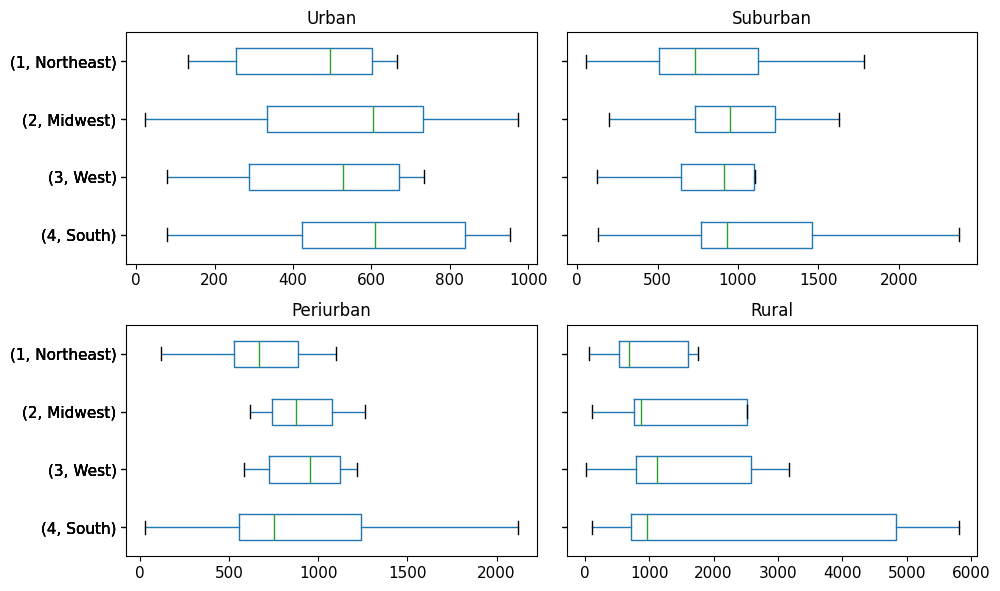

In [59]:
# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharey=True)

# Boxplot for Value1 and Value2 in the first subplot
data[data['city type'] == 'urban'].groupby(['REGION_order','REGION'])['per_cap_mass_at_2020'].describe().T.boxplot(ax=axs[0, 0], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 0].set_title('Urban')
axs[0, 0].invert_yaxis()
# # Boxplot for Value1 and Value3 in the second subplot
data[data['city type'] == 'suburban'].groupby(['REGION_order','REGION'])['per_cap_mass_at_2020'].describe().T.boxplot(ax=axs[0, 1], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 1].set_title('Suburban')
# # Boxplot for Value2 and Value3 in the third subplot
data[data['city type'] == 'periurban'].groupby(['REGION_order','REGION'])['per_cap_mass_at_2020'].describe().T.boxplot(ax=axs[1, 0], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 0].set_title('Periurban')
# # Boxplot for all three values in the fourth subplot
data[data['city type'] == 'rural'].groupby(['REGION_order','REGION'])['per_cap_mass_at_2020'].describe().T.boxplot(ax=axs[1, 1], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 1].set_title('Rural')
# Adjust layout
plt.tight_layout()

for ax in fig.axes:
    ax.tick_params(axis='both', which='major', labelsize=11)
    # ax.tick_params(axis='both', which='minor', labelsize=11)
    # ax.axis("off")
    ax.grid(False)
    

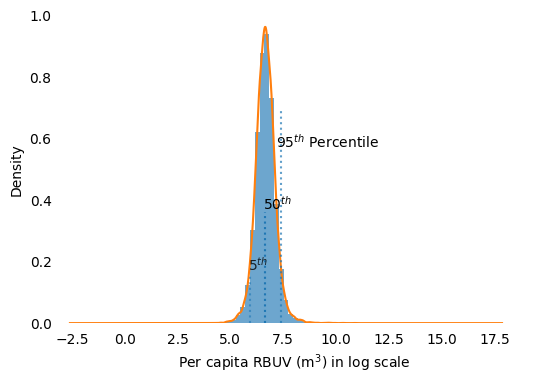

In [60]:
avocado = np.log(building_with_pop['per_cap_mass_at_2020'])
# sns.histplot(np.log(data['per_cap_mass_at_2020']), alpha = 0.8, color= 'grey', linewidth=0.2)
# citytype_name = ['urban', 'suburban', 'periurban', 'rural']

fig, ax = plt.subplots(figsize = (6,4))

# Plot
# Plot histogram
avocado.plot(kind = "hist", density = True, alpha = 0.65, bins = 45) # change density to true, because KDE uses density
# Plot KDE
avocado.plot(kind = "kde")

# Quantile lines
quant_5, quant_25, quant_50, quant_75, quant_95 = avocado.quantile(0.05), avocado.quantile(0.25), avocado.quantile(0.5), avocado.quantile(0.75), avocado.quantile(0.95)
quants = [[quant_5, 0.6, 0.16], [quant_50, 1, 0.36],  [quant_95, 0.7, 0.7]] # [quant_25, 0.8, 0.26], [quant_75, 0.8, 0.46], 
for i in quants:
    ax.axvline(i[0], alpha = i[1], ymax = i[2], linestyle = ":")


# X
ax.set_xlabel("Per capita RBUV (m$^3$) in log scale")
# Limit x range to 0-4
x_start, x_end = -3, 19
ax.set_xlim(x_start, x_end)
# ax.set_xscale('log')

# Y
ax.set_ylim(0, 1)

# ax.set_yticklabels([])
# ax.set_ylabel("")

# Annotations
ax.text(quant_5-.1, 0.17, "5$^{th}$", size = 10, alpha = 0.8)
# ax.text(quant_25-.13, 0.27, "25th", size = 11, alpha = 0.8)
ax.text(quant_50-.13, 0.37, "50$^{th}$", size = 10, alpha = 1)
# ax.text(quant_75-.13, 0.47, "75th", size = 11, alpha = 0.8)
ax.text(quant_95-.25, 0.57, "95$^{th}$ Percentile", size = 10, alpha =1)

# Overall
ax.grid(False)
# ax.set_title("Avocado Prices in U.S. Markets", size = 17, pad = 10)

    # Remove ticks and spines
ax.tick_params(left = False, bottom = False)
for ax, spine in ax.spines.items():
    spine.set_visible(False)
    
plt.show()

In [61]:
# avocado.min(), avocado.max()

### Model comparision Pruned Nonpruned F_test

In [62]:
building_with_pop['per_cap_mass_at_2020'] =  building_with_pop['volume_Res_2020'] / building_with_pop['CensusPop_20']
# building_with_pop['avg_HU_size_sqm_Res'] = building_with_pop['surface_Res_2020'] / building_with_pop['HUs_Total']
stocks_with_pop = building_with_pop[building_with_pop['CensusPop_20'] != 0]
stocks_with_pop = stocks_with_pop[stocks_with_pop['city type'] == 'suburban']
print(stocks_with_pop.shape)

infra_col ='surface_Res_2020'
pop_col = 'CensusPop_20'
df = stocks_with_pop.copy()


### ============== PRUNING ============== ###
# Set the threshold to the 90th percentile
threshold = df[pop_col].quantile(0.9)
# Filter the DataFrame to include only points in the to 10%
df_pruned = df[df[pop_col] > threshold]
print(df_pruned.shape)

y = np.log(df[infra_col].astype(float))
x = np.log(df[pop_col].astype(float))

y_pruned = np.log(df_pruned[infra_col].astype(float))
x_pruned = np.log(df_pruned[pop_col].astype(float)) 

m01 = sm.ols("y ~ x", data={"y": y, "x": x}).fit()
m02 = sm.ols("y_pruned ~ x_pruned", data={"y_pruned": y_pruned, "x_pruned": x_pruned}).fit()
anova_results= anova_lm(m01, m02)
print(anova_results)
print('\n')

if anova_results['Pr(>F)'][1] < 0.005:
    print(f"Since {anova_results['Pr(>F)'][1]} < 0.005, difference is significant")
    print("Built seperate models")


(6885, 88)
(689, 88)
   df_resid          ssr  df_diff      ss_diff         F        Pr(>F)
0    6883.0  1144.031709      0.0          NaN       NaN           NaN
1     687.0    55.824445   6196.0  1088.207264  2.161387  1.018318e-34


Since 1.018318461217431e-34 < 0.005, difference is significant
Built seperate models


c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


#### For 2030

In [63]:
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'D:\Work\Box Sync\Quantify Infrastructure\Scripts\scenarios')
from functions.functions_scaling import find_scale_parameters, find_next_stock, process_stock_at_t

building_clean = building_with_pop.dropna(subset=['CensusPop_20', 'ssp22040', 'surface_Res_2020']).reset_index(drop=True)
building_clean['avg_HU_size_Res_sqm'] = building_clean['volume_Res_2020'] / building_clean[' !!Total:']

# converting building footprint to gross area
building_clean['surface_Res_gross_2020'] = building_clean['surface_Res_2020'] * building_clean['floors'] 
print("Shape of the clean dataset with nonzero values:==", building_clean.shape)


building_clean.groupby('city type')[['volume_Res_2020', 'per_cap_mass_at_2020']].describe().round(2)

Shape of the clean dataset with nonzero values:== (30581, 89)


volume_Res_2020                                        \
                          count         mean           std        min   
city type                                                               
not enough data            37.0    106785.92  4.916970e+04   19210.53   
periurban                5700.0   7540243.11  1.520710e+07    6252.96   
rural                   17647.0    545905.79  7.052359e+05    2353.19   
suburban                 6885.0  17654970.73  5.148114e+07   42324.44   
urban                     312.0  92735393.53  2.654962e+08  182629.08   

                                                                     \
                        25%          50%          75%           max   
city type                                                             
not enough data    79443.96     99446.47    129870.00  2.563235e+05   
periurban        1206827.18   3294764.46   7301336.96  2.899520e+08   
rural             138942.00    288777.56    665803.27  2.547815e+07   
suburban         1772723.83   5430911.78  15473050.99  1.577825e+09   
urban            6738150.60  22373901.43  65074765.85  2.760422e+09   

                per_cap_mass_at_2020                                           \
                               count    mean      std     min     25%     50%   
city type                                                                       
not enough data                 37.0  934.96   334.91  243.17  685.76  936.82   
periurban                     5700.0  825.09   774.14   28.49  542.02  720.67   
rural                        17647.0  918.94  2865.33   12.43  584.14  766.96   
suburban                      6885.0  921.70   661.40   51.86  635.68  837.14   
urban                          312.0  659.93   359.58  167.62  458.66  593.51   

                                     
                     75%        max  
city type                            
not enough data  1175.54    1546.88  
periurban         959.50   30589.29  
rural            1024.31  341691.09  
suburban         1072.84   28832.58  
urban             741.36    3651.69

(30581, 24)
Initial dataframe:====
(30581, 24)
Shape of the dataframe for urban:====
(312, 25)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(280, 25)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     3679.
Date:                Tue, 08 Oct 2024   Prob (F-statistic):          2.38e-162
Time:                        15:48:43   Log-Likelihood:                -127.84
No. Observations:                 280   AIC:                             259.7
Df Residuals:                     278   BIC:                             267.0
Df Model:                           1                                         
Covariance Type:      

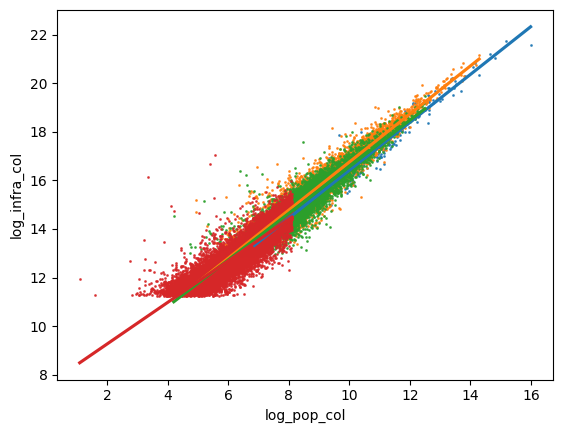

In [64]:
stock_columns_2020 = ['surface_Res_2020', 'surface_Res_gross_2020', 'volume_Res_2020']

current_stock_col = stock_columns_2020[2]
current_pop_col = 'CensusPop_20'
next_pop_col = 'ssp22030'
t = 2030

building_clean['per_cap_mass_at_2020'] =  building_clean[current_stock_col] / building_clean['CensusPop_20']

building_clean['stock_at_t0'] = building_clean['volume_Res_2020']
df_for_analysis = building_clean[['GEOID', 'State', 'NAMELSAD', 'ALAND', 'ua-to-place allocation factor_max', 'population_ua_max', 'weighted_HU_density_sqmi', 'city type', 'median_income',
                                  'CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100',
                                  'avg_HU_size_Res_sqm','surface_Res_2020','surface_Res_gross_2020', 'volume_Res_2020', 'stock_at_t0']]

df_for_2030 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2030, on ='GEOID')
building_clean = building_clean.merge(df_for_2030, on ='GEOID')
print(building_clean.shape)

In [65]:
df_for_analysis.columns

Index(['GEOID', 'State', 'NAMELSAD', 'ALAND',
       'ua-to-place allocation factor_max', 'population_ua_max',
       'weighted_HU_density_sqmi', 'city type', 'median_income',
       'CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050',
       'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100',
       'avg_HU_size_Res_sqm', 'surface_Res_2020', 'surface_Res_gross_2020',
       'volume_Res_2020', 'stock_at_t0', 'per_cap_mass_t1',
       'per_cap_mass_at_2030', 'surface_Res_at_2030',
       'HU_density_sqmi_at_2030', 'ua_population_at_2030', 'citytype_at_2030'],
      dtype='object')

In [66]:
# df_for_analysis[(df_for_analysis['city type'] != 'urban') & (df_for_analysis['citytype_at_2030'] == 'urban')][['State', 'NAMELSAD', 'per_cap_mass_t1','weighted_HU_density_sqmi', 'HU_density_sqmi_at_2030',
# 'population_ua_max',  'ua_population_at_2030']].sort_values('per_cap_mass_t1').head(30)

#### For 2040 - 2100

(30544, 30)
Initial dataframe:====
(30544, 30)
Shape of the dataframe for urban:====
(325, 30)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(292, 30)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     3889.
Date:                Tue, 08 Oct 2024   Prob (F-statistic):          4.84e-170
Time:                        15:50:09   Log-Likelihood:                -125.70
No. Observations:                 292   AIC:                             255.4
Df Residuals:                     290   BIC:                             262.7
Df Model:                           1                                         
Covariance Type:      

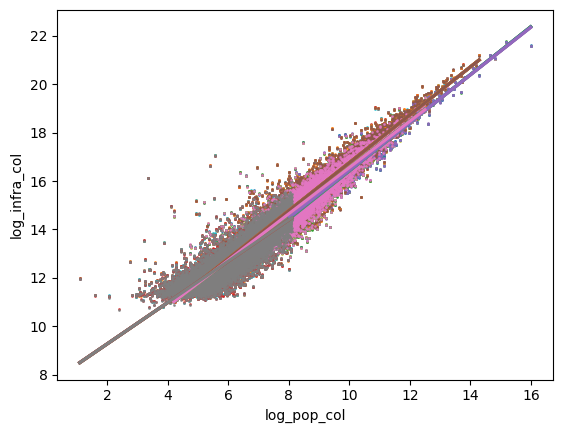

In [67]:
current_stock_col ='surface_Res_at_2030'
current_pop_col = 'ssp22030'
next_pop_col = 'ssp22040'
t = 2040

df_for_2040 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2040, on ='GEOID')
building_clean = building_clean.merge(df_for_2040, on ='GEOID')
print(building_clean.shape)


current_stock_col ='surface_Res_at_2040'
current_pop_col = 'ssp22040'
next_pop_col = 'ssp22050'
t = 2050

df_for_2050 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2050, on ='GEOID')
building_clean = building_clean.merge(df_for_2050, on ='GEOID')
print(building_clean.shape)

current_stock_col ='surface_Res_at_2050'
current_pop_col = 'ssp22050'
next_pop_col = 'ssp22060'
t = 2060

df_for_2060 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2060, on ='GEOID')
building_clean = building_clean.merge(df_for_2060, on ='GEOID')
print(building_clean.shape)

current_stock_col ='surface_Res_at_2060'
current_pop_col = 'ssp22060'
next_pop_col = 'ssp22070'
t = 2070

df_for_2070 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2070, on ='GEOID')
building_clean = building_clean.merge(df_for_2070, on ='GEOID')
print(building_clean.shape)

current_stock_col ='surface_Res_at_2070'
current_pop_col = 'ssp22070'
next_pop_col = 'ssp22080'
t = 2080

df_for_2080 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2080, on ='GEOID')
building_clean = building_clean.merge(df_for_2080, on ='GEOID')
print(building_clean.shape)

current_stock_col ='surface_Res_at_2080'
current_pop_col = 'ssp22080'
next_pop_col = 'ssp22090'
t = 2090

df_for_2090 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2090, on ='GEOID')
building_clean = building_clean.merge(df_for_2090, on ='GEOID')
print(building_clean.shape)

current_stock_col ='surface_Res_at_2090'
current_pop_col = 'ssp22090'
next_pop_col = 'ssp22100'
t = 2100

df_for_2100 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2100, on ='GEOID')
building_clean = building_clean.merge(df_for_2100, on ='GEOID')
print(building_clean.shape)

<Axes: >

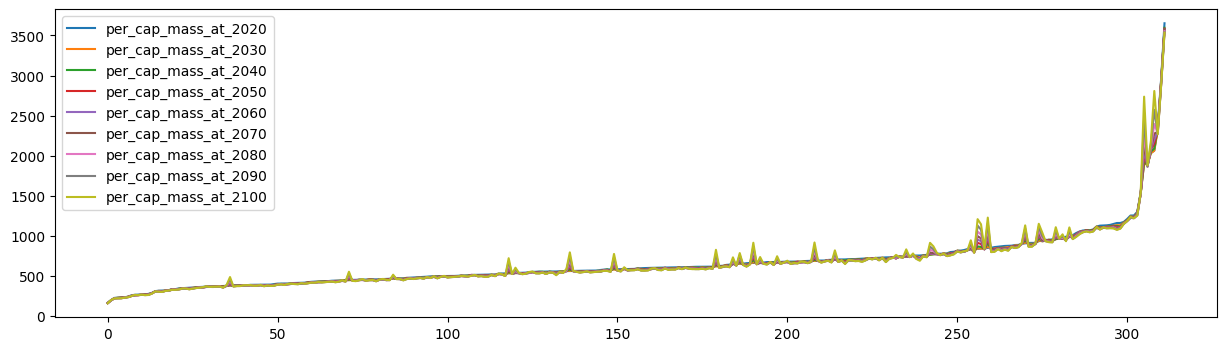

In [68]:
fig, ax = plt.subplots(figsize=(15, 4))
building_clean[building_clean['city type'] == 'urban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040', 'per_cap_mass_at_2050','per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070', 'per_cap_mass_at_2080','per_cap_mass_at_2090',
                                                        'per_cap_mass_at_2100',]].sort_values(by = 'per_cap_mass_at_2020').reset_index(drop=True).plot(ax=ax)

In [69]:
# building_with_pop[building_with_pop['NAMELSAD'] == 'Chicago city'][['State', 'NAMELSAD','ssp22030', 'ssp22080', 'ssp22090','ssp22100','surface_Res_2020','volume_Res_2020',
#                                                                     'surface_2020','volume_2020','height_building', 'floors']]

In [70]:
1.363073e+09/1.347756e+08, 1.347756e+08*3, 1.776373e+09/1.684657e+08//3.048

(10.11364816776924, 404326800.0, 3.0)

In [71]:
building_clean[['volume_Res_2020', 'surface_Res_at_2030','surface_Res_at_2050','surface_Res_at_2100']]

,volume_Res_2020,surface_Res_at_2030,surface_Res_at_2050,surface_Res_at_2100
0,1.614517e+06,1.669762e+06,1.745478e+06,1.848499e+06
1,4.296071e+04,4.565454e+04,4.983745e+04,5.622554e+04
2,5.438807e+05,5.461401e+05,5.461401e+05,5.461401e+05
3,2.171212e+06,2.211637e+06,2.217939e+06,2.217939e+06
4,4.287380e+05,4.354543e+05,4.410823e+05,4.486491e+05
...,...,...,...,...
30539,7.360783e+04,7.496367e+04,7.657033e+04,7.932008e+04
30540,9.668966e+04,9.838940e+04,1.003025e+05,1.068904e+05
30541,9.302250e+05,9.645354e+05,1.014068e+06,1.098609e+06
30542,9.006687e+04,9.563658e+04,1.060242e+05,1.293804e+05


In [72]:
# building_clean['CensusPop_20'].round(0) * building_clean['per_cap_mass_at_2020'], \
# building_clean['ssp22050'].round(0) * building_clean['per_cap_mass_at_2050'], \
# building_clean['ssp22100'].round(0) * building_clean['per_cap_mass_at_2100']

In [73]:
(np.sum(building_clean[(building_clean['per_cap_mass_at_2050'] > building_clean['per_cap_mass_at_2020'])]['surface_Res_at_2050'] - \
building_clean[(building_clean['per_cap_mass_at_2050'] > building_clean['per_cap_mass_at_2020'])]['volume_Res_2020']) / (187*4.6)).round(0), \
(np.sum(building_clean[(building_clean['per_cap_mass_at_2100'] > building_clean['per_cap_mass_at_2050'])]['surface_Res_at_2100'] - \
building_clean[(building_clean['per_cap_mass_at_2100'] > building_clean['per_cap_mass_at_2050'])]['surface_Res_at_2050']) / (187*4.6)).round(0)


(214972.0, 1748088.0)

In [74]:
# 31568-30533

In [75]:
building_clean[(building_clean['per_cap_mass_at_2050'] > building_clean['per_cap_mass_at_2020'])][['volume_Res_2020', 'surface_Res_at_2030','surface_Res_at_2050','surface_Res_at_2100',
                                                                                                   'per_cap_mass_at_2050', 'per_cap_mass_at_2100', 'ssp22050', 'ssp22100']]

,volume_Res_2020,surface_Res_at_2030,surface_Res_at_2050,surface_Res_at_2100,per_cap_mass_at_2050,per_cap_mass_at_2100,ssp22050,ssp22100
2,5.438807e+05,5.461401e+05,5.461401e+05,5.461401e+05,701.979555,858.710839,777.721488,636.435207
3,2.171212e+06,2.211637e+06,2.217939e+06,2.217939e+06,862.340030,906.761471,2571.506064,2446.128478
5,1.023877e+06,1.023877e+06,1.023877e+06,1.023877e+06,1027.989208,1343.670933,995.672843,761.781631
7,4.066977e+04,4.066977e+04,4.066977e+04,4.066977e+04,1452.491737,1848.625847,28.397473,22.006443
8,2.378719e+06,2.378719e+06,2.378719e+06,2.378719e+06,1093.161181,1360.045014,2176.363516,1749.301247
...,...,...,...,...,...,...,...,...
30502,6.824516e+05,6.824516e+05,6.824516e+05,6.929190e+05,1343.408685,1302.479266,508.436891,531.622989
30508,3.268026e+05,3.297440e+05,3.297440e+05,3.297440e+05,524.235245,636.571369,628.878673,517.887013
30511,2.795348e+05,2.795348e+05,2.795348e+05,2.795348e+05,1954.788866,2409.782826,142.744884,115.521186
30523,7.349778e+04,7.497365e+04,7.497365e+04,7.497365e+04,2342.926718,2499.121833,31.825684,30.053340


In [76]:
data = building_clean
data['percent change from 2020-2040'] = (data['per_cap_mass_at_2040'] - data['per_cap_mass_at_2020'])/data['per_cap_mass_at_2020']
data['percent change from 2040-2060'] = (data['per_cap_mass_at_2060'] - data['per_cap_mass_at_2040'])/data['per_cap_mass_at_2040']
data['percent change from 2060-2080'] = (data['per_cap_mass_at_2080'] - data['per_cap_mass_at_2060'])/data['per_cap_mass_at_2060']
data['percent change from 2080-2100'] = (data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2080'])/data['per_cap_mass_at_2080']

In [77]:
data[data['NAMELSAD']== 'Phoenix city'][['city type', 'CensusPop_20','ssp22030', 'ssp22100', 'NAMELSAD',#'ua-to-place allocation factor_max','volume_Res_2020',
'avg_HU_size_Res_sqm', 'weighted_HU_density_sqmi', 'HU_density_sqmi_at_2030', 'HU_density_sqmi_at_2040', 'HU_density_sqmi_at_2100']]

,city type,CensusPop_20,ssp22030,ssp22100,NAMELSAD,avg_HU_size_Res_sqm,weighted_HU_density_sqmi,HU_density_sqmi_at_2030,HU_density_sqmi_at_2040,HU_density_sqmi_at_2100
668,suburban,1608139.0,1.788167e+06,2.560021e+06,Phoenix city,2501.498555,2492.959087,2608.120804,2709.236987,3085.199290
21866,periurban,4475.0,4.904398e+03,6.446007e+03,Phoenix city,2214.461799,465.129621,560.389673,637.754125,887.873473


In [78]:
# data[(data['city type'] != 'urban')][['city type', 'CensusPop_20','ssp22030', 'ssp22100', 'NAMELSAD',#'ua-to-place allocation factor_max','volume_Res_2020',
# 'avg_HU_size_Res_sqm', 'weighted_HU_density_sqmi', 'HU_density_sqmi_at_2030', 'HU_density_sqmi_at_2040', 'HU_density_sqmi_at_2100']].sort_values('CensusPop_20').tail(10)

In [79]:
data['diff_pop'] = (data['ssp22030'] - data['CensusPop_20']).round(0)
data['diff_HU'] = (data['HU_density_sqmi_at_2030'] - data['weighted_HU_density_sqmi']).round(0)
data['area_sqmi'] = (data['ALAND'] * 3.86102e-7).round(2)
data['pop_per_HU'] = (data['diff_pop'] / (data['diff_HU'] * data['area_sqmi'])).round(0)
data.columns

Index(['STATEFP', 'PLACEFP', 'PLACENS', 'GEOID', 'NAME_x', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'PCICBSA', 'PCINECTA',
       ...
       'ua_population_at_2100', 'citytype_at_2100',
       'percent change from 2020-2040', 'percent change from 2040-2060',
       'percent change from 2060-2080', 'percent change from 2080-2100',
       'diff_pop', 'diff_HU', 'area_sqmi', 'pop_per_HU'],
      dtype='object', length=138)

In [80]:
data[(data['citytype_at_2100'] == 'urban') & (data['city type'] != 'urban')][['GEOID', 'CensusPop_20','ssp22030', 'ssp22100', 'NAMELSAD','population_ua_max' , #'ua-to-place allocation factor_max','volume_Res_2020',
# 'avg_HU_size_Res_sqm', 'weighted_HU_density_sqmi', 'HU_density_sqmi_at_2030', 'HU_density_sqmi_at_2100', 
'diff_pop', 'diff_HU', 'area_sqmi',  'pop_per_HU', 'citytype_at_2030', 'citytype_at_2080', 'citytype_at_2100']].sort_values(['pop_per_HU','citytype_at_2030'])

,GEOID,CensusPop_20,ssp22030,ssp22100,NAMELSAD,population_ua_max,diff_pop,diff_HU,area_sqmi,pop_per_HU,citytype_at_2030,citytype_at_2080,citytype_at_2100
2110,0639259,17644.0,19322.773550,23724.664710,Laguna Woods city,646859.0,1679.0,338.0,3.34,1.0,suburban,urban,urban
4385,1216550,5179.0,5562.190339,6850.463649,Daytona Beach Shores city,402471.0,383.0,502.0,0.85,1.0,suburban,urban,urban
4389,1247625,19115.0,21448.674650,29817.051660,Naples city,425675.0,2334.0,162.0,12.30,1.0,suburban,urban,urban
4606,1234012,16908.0,20388.432290,35855.720950,Iona CDP,599242.0,3480.0,399.0,6.63,1.0,suburban,suburban,urban
4730,1253200,7312.0,7964.809686,10300.120990,Ormond-by-the-Sea CDP,402471.0,653.0,234.0,2.02,1.0,suburban,suburban,urban
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15963,3271400,205618.0,239198.534500,399011.163500,Sunrise Manor CDP,66336356.0,33581.0,201.0,33.71,5.0,periurban,periurban,urban
1722,0668294,32127.0,35856.789280,49409.701840,San Pablo city,3269475.0,3730.0,273.0,2.62,5.0,urban,urban,urban
1760,0650398,56173.0,62045.875120,81473.620890,National City city,3070589.0,5873.0,150.0,7.29,5.0,urban,urban,urban
5629,1507450,16415.0,17713.969770,28047.266480,Ewa Beach CDP,853252.0,1299.0,168.0,1.19,6.0,periurban,periurban,urban


In [81]:
data[(data['citytype_at_2100'] == 'urban') & (data['city type'] != 'urban')][['GEOID', 'CensusPop_20',#'ssp22030', 'ssp22100', 
                                                                              'NAMELSAD',#'population_ua_max' , #'ua-to-place allocation factor_max','volume_Res_2020',
# 'avg_HU_size_Res_sqm', 'weighted_HU_density_sqmi', 'HU_density_sqmi_at_2030', 'HU_density_sqmi_at_2100', 
#'diff_pop', 'diff_HU', 'area_sqmi',  
# 'pop_per_HU', 'citytype_at_2030', 
'citytype_at_2050', 'citytype_at_2100'
]].sort_values(['citytype_at_2050',])

,GEOID,CensusPop_20,NAMELSAD,citytype_at_2050,citytype_at_2100
5629,1507450,16415.0,Ewa Beach CDP,periurban,urban
5753,1572650,18658.0,Wahiawa CDP,periurban,urban
2466,0624722,35834.0,Foothill Farms CDP,periurban,urban
15976,3283800,49061.0,Whitney CDP,periurban,urban
15963,3271400,205618.0,Sunrise Manor CDP,periurban,urban
...,...,...,...,...,...
5774,1579700,43485.0,Waipahu CDP,urban,urban
4715,1250638,25062.0,Oak Ridge CDP,urban,urban
4279,1224150,5582.0,Fort Myers Beach town,urban,urban
4828,1267258,26858.0,South Bradenton CDP,urban,urban


In [82]:
building_clean[(building_clean['per_cap_mass_at_2020'] < building_clean['per_cap_mass_at_2050']) & (building_clean['ssp22050'] > building_clean['CensusPop_20'])][['NAMELSAD', 'CensusPop_20',
              'ssp22040', 'ssp22050', 'per_cap_mass_at_2020','per_cap_mass_at_2040', 'per_cap_mass_at_2050','volume_Res_2020','surface_Res_at_2040','surface_Res_at_2050']]

,NAMELSAD,CensusPop_20,ssp22040,ssp22050,per_cap_mass_at_2020,per_cap_mass_at_2040,per_cap_mass_at_2050,volume_Res_2020,surface_Res_at_2040,surface_Res_at_2050
3,Trinity town,2526.0,2585.723001,2571.506064,859.545385,857.671523,862.340030,2.171212e+06,2.217939e+06,2.217939e+06
13,Douglas town,761.0,779.787615,767.239267,950.945531,935.371770,951.225529,7.236695e+05,7.295900e+05,7.295900e+05
14,Sardis City town,1814.0,1881.716909,1871.880349,755.693229,752.968396,756.990663,1.370828e+06,1.417087e+06,1.417087e+06
33,Napier Field town,409.0,415.458176,412.722939,873.080224,873.802207,878.033695,3.570898e+05,3.626279e+05,3.626279e+05
41,Hueytown city,16776.0,17190.878060,16977.753120,752.652298,746.397858,755.761902,1.262649e+07,1.283133e+07,1.283133e+07
...,...,...,...,...,...,...,...,...,...,...
30357,Star Valley Ranch town,1866.0,1905.960411,1868.785079,454.425173,448.124017,456.995386,8.479574e+05,8.541244e+05,8.541244e+05
30427,Evanston city,11747.0,11858.314110,11775.697080,817.065617,820.076583,825.787035,9.598070e+06,9.724468e+06,9.724468e+06
30455,Bedford CDP,465.0,475.077553,466.782824,718.742813,709.800225,721.959544,3.342154e+05,3.371551e+05,3.371551e+05
30478,Fontenelle CDP,5.0,5.250000,5.192536,6282.443922,6494.379964,6494.379964,3.141222e+04,3.247190e+04,3.247190e+04


In [83]:
data[(data['city type'] != 'urban') & (data['pop_per_HU']>0)][['city type', 'CensusPop_20','ssp22030', 'ssp22100', 'NAMELSAD','population_ua_max','avg_HU_size_Res_sqm', #'ua-to-place allocation factor_max', 'avg_HU_size_Res_sqm',
 'weighted_HU_density_sqmi', 'HU_density_sqmi_at_2030', #'HU_density_sqmi_at_2100', 'citytype_at_2030', 'citytype_at_2100',
 'diff_pop', 'diff_HU', 'area_sqmi', 'pop_per_HU']].dropna().sort_values(['avg_HU_size_Res_sqm','weighted_HU_density_sqmi']).tail(50)

,city type,CensusPop_20,ssp22030,ssp22100,NAMELSAD,population_ua_max,avg_HU_size_Res_sqm,weighted_HU_density_sqmi,HU_density_sqmi_at_2030,diff_pop,diff_HU,area_sqmi,pop_per_HU
26960,rural,21.0,23.314773,30.253124,Laredo Ranchettes CDP,66336356.0,25341.052941,247.995472,248.647826,2.0,1.0,0.55,4.0
8357,suburban,379.0,413.727513,576.884269,Riverdale city,285326.0,25751.053291,399.537257,407.376475,35.0,8.0,1.84,2.0
16678,suburban,2200.0,2399.316467,3489.520265,Ramapo College of New Jersey CDP,19427703.0,27610.124421,54.307811,56.193314,199.0,2.0,0.48,207.0
3358,rural,16.0,18.425896,29.188982,Lakeside town,2687234.0,28964.562923,1513.587889,1518.597834,2.0,5.0,0.19,2.0
26031,rural,156.0,186.353348,343.450643,Thompsons town,66336356.0,30387.626719,36.373976,37.583024,30.0,1.0,4.93,6.0
24942,rural,53.0,61.599647,146.385001,Rolland Colony CDP,66336356.0,32143.881046,4.891723,5.838481,9.0,1.0,0.24,38.0
24890,rural,127.0,128.110380,120.615300,Grassland Colony CDP,66336356.0,35148.382745,1.242228,1.285492,1.0,0.0,0.43,inf
3777,suburban,2884.0,3027.054804,3447.831034,Fairfield University CDP,916408.0,35905.751885,905.107549,908.634433,143.0,4.0,0.34,105.0
4310,suburban,1056.0,1184.533423,1677.311670,Medley town,6077975.0,36732.971071,280.913869,290.168032,129.0,9.0,5.08,3.0
15006,rural,78.0,81.343228,96.916328,Big Stone Colony CDP,66336356.0,37408.000000,2.031478,2.093097,3.0,0.0,0.94,inf


In [84]:
325-312, 336-312, 360-312, 

(13, 24, 48)

In [85]:
data[['city type', 'citytype_at_2030',  'citytype_at_2050', 'citytype_at_2060','citytype_at_2100']].apply(pd.Series.value_counts)

,city type,citytype_at_2030,citytype_at_2050,citytype_at_2060,citytype_at_2100
rural,17647,17647,17647,17647,17647
suburban,6885,6876,6866,6864,6835
periurban,5700,5696,5693,5692,5688
urban,312,325,338,341,374


### Plots

In [86]:
data = building_clean

In [87]:
building_clean[(building_clean['city type'] == 'suburban') & (building_clean['percent change from 2080-2100'] < 0)][['STATEFP', 'NAMELSAD','CensusPop_20', 'ssp22080', 'ssp22100', 'future trend from SSP 2', 'per_cap_mass_at_2020',
                                                                                                                      'per_cap_mass_at_2080','per_cap_mass_at_2100', 'percent change from 2080-2100']].sort_values(by='percent change from 2080-2100')

,STATEFP,NAMELSAD,CensusPop_20,ssp22080,ssp22100,future trend from SSP 2,per_cap_mass_at_2020,per_cap_mass_at_2080,per_cap_mass_at_2100,percent change from 2080-2100
1829,06,Imperial city,20263.0,24983.665160,39122.308680,increasing,452.075621,442.241922,424.834693,-0.039361
1827,06,El Centro city,44322.0,55976.511600,83120.224770,increasing,660.103923,643.237175,617.925140,-0.039351
19493,38,Fargo city,125990.0,347743.164300,428966.352800,increasing,736.034241,657.651034,633.597149,-0.036575
2122,06,Calipatria city,6515.0,8037.011141,12513.295270,increasing,310.126329,304.062114,294.083314,-0.032818
19545,38,Williston city,29160.0,166434.736800,217148.135000,increasing,710.396172,592.337953,576.276906,-0.027115
...,...,...,...,...,...,...,...,...,...,...
10647,22,Sulphur city,21809.0,28760.913920,29006.469910,increasing,1490.047808,1443.752285,1443.633065,-0.000083
10798,22,Prien CDP,7745.0,10226.759900,10322.616770,increasing,1100.354926,1069.782438,1069.699498,-0.000078
28681,53,Mount Vernon city,35219.0,46692.430460,47052.881560,increasing,825.868454,802.836703,802.781382,-0.000069
11531,25,Fitchburg city,41946.0,55605.596100,56090.937580,increasing,438.616560,425.478667,425.469606,-0.000021


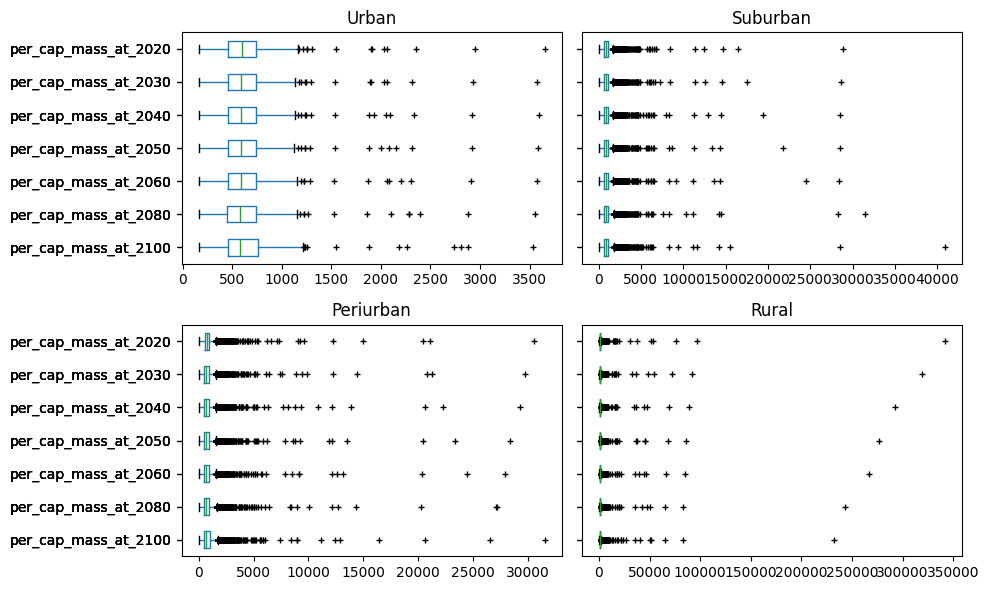

In [88]:
columns_boxplot = ['per_cap_mass_at_2100', 'per_cap_mass_at_2080','per_cap_mass_at_2060','per_cap_mass_at_2050','per_cap_mass_at_2040','per_cap_mass_at_2030','per_cap_mass_at_2020']

# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharey=True)

# Boxplot for Value1 and Value2 in the first subplot
building_clean[building_clean['city type'] == 'urban'][columns_boxplot].boxplot(ax=axs[0, 0], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 0].set_title('Urban')
# # Boxplot for Value1 and Value3 in the second subplot
building_clean[building_clean['city type'] == 'suburban'][columns_boxplot].boxplot(ax=axs[0, 1], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 1].set_title('Suburban')
# # Boxplot for Value2 and Value3 in the third subplot
building_clean[building_clean['city type'] == 'periurban'][columns_boxplot].boxplot(ax=axs[1, 0], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 0].set_title('Periurban')
# # Boxplot for all three values in the fourth subplot
building_clean[building_clean['city type'] == 'rural'][columns_boxplot].boxplot(ax=axs[1, 1], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 1].set_title('Rural')
# Adjust layout
plt.tight_layout()

for ax in fig.axes:
    # ax.axis("off")
    ax.grid(False)

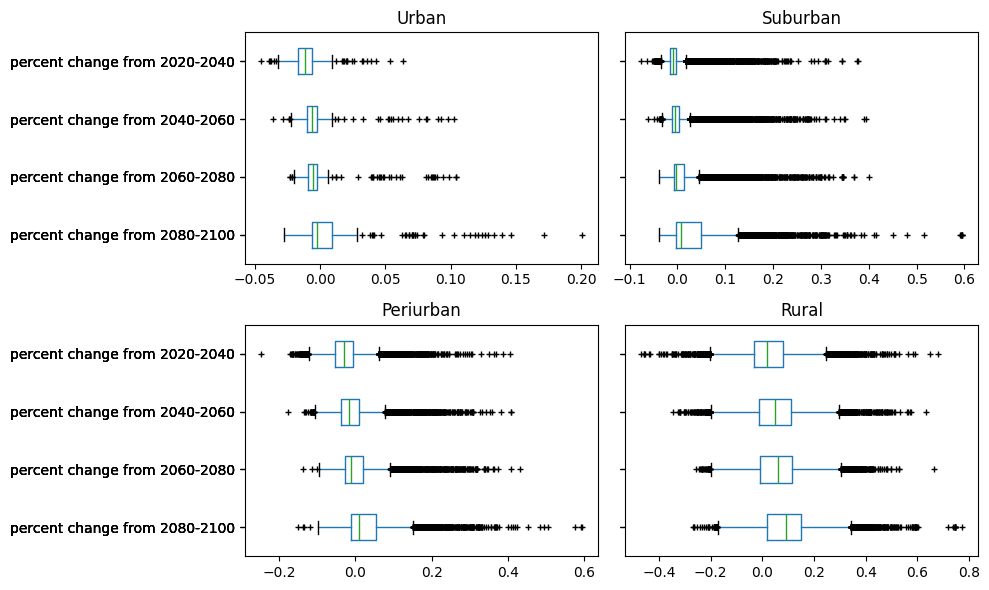

In [89]:
columns_boxplot = ['percent change from 2080-2100', 'percent change from 2060-2080','percent change from 2040-2060','percent change from 2020-2040']

# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharey=True)

# Boxplot for Value1 and Value2 in the first subplot
building_clean[building_clean['city type'] == 'urban'][columns_boxplot].boxplot(ax=axs[0, 0], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 0].set_title('Urban')
# # Boxplot for Value1 and Value3 in the second subplot
building_clean[building_clean['city type'] == 'suburban'][columns_boxplot].boxplot(ax=axs[0, 1], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 1].set_title('Suburban')
# # Boxplot for Value2 and Value3 in the third subplot
building_clean[building_clean['city type'] == 'periurban'][columns_boxplot].boxplot(ax=axs[1, 0], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 0].set_title('Periurban')
# # Boxplot for all three values in the fourth subplot
building_clean[building_clean['city type'] == 'rural'][columns_boxplot].boxplot(ax=axs[1, 1], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 1].set_title('Rural')
# Adjust layout
plt.tight_layout()

for ax in fig.axes:
    # ax.axis("off")
    ax.grid(False)

In [90]:
from matplotlib.pyplot import plot, savefig
import matplotlib

C:\Users\uttar\AppData\Local\Temp\ipykernel_17136\2890957103.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontdict={'fontsize' :12})
C:\Users\uttar\AppData\Local\Temp\ipykernel_17136\2890957103.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["2020-2040","2040-2060", "2060-2080", "2080-2100"], fontdict={'fontsize' :12})
C:\Users\uttar\AppData\Local\Temp\ipykernel_17136\2890957103.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontdict={'fontsize' :12})
C:\Users\uttar\AppData\Local\Temp\ipykernel_17136\2890957103.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() 

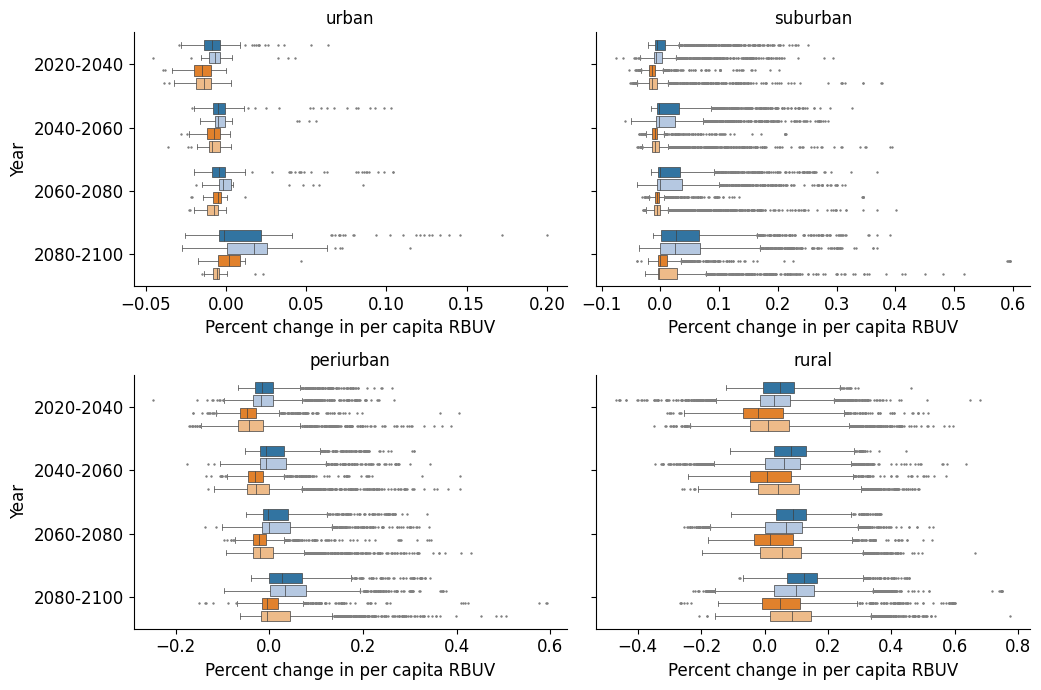

In [91]:
custom_order = ['Northeast','Midwest', 'West','South'] 
citytype_name = ['urban', 'suburban', 'periurban', 'rural']
flierprops = dict(marker='+', markerfacecolor='None', markersize=2,  markeredgecolor='grey')

fig, ax = plt.subplots(nrows = 2, ncols = 2,figsize=(14, 7), sharey = True)
for ax, city in zip(ax.flatten(), citytype_name):
    df = building_clean[(building_clean['city type'] == city)]
    df_melted = pd.melt(df, id_vars='REGION', value_vars=['percent change from 2020-2040','percent change from 2040-2060', 'percent change from 2060-2080','percent change from 2080-2100'])
    sns.boxplot(ax =ax, data=df_melted,  y='variable', x='value', hue="REGION", gap= 0.15, legend=True, linewidth = 0.5, hue_order=custom_order, palette= 'tab20',
                flierprops=flierprops)
    ax.get_legend().remove()
    ax.set_xticklabels(ax.get_xticklabels(), fontdict={'fontsize' :12}) 
    ax.set_yticklabels(["2020-2040","2040-2060", "2060-2080", "2080-2100"], fontdict={'fontsize' :12}) 
    ax.set_xlabel('Percent change in per capita RBUV', fontdict={'fontsize' :12})  
    ax.set_ylabel('Year', fontdict={'fontsize' :12}) 
    ax.set_title(city) 
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    handles, labels = ax.get_legend_handles_labels()

matplotlib.rcParams['axes.edgecolor'] = '#000000'
# fig.legend(handles, labels, loc='lower right',  ncol=4, bbox_to_anchor=(0.75, 1), frameon=False)
plt.tight_layout(rect=[0, 0, 0.75, 1])

plt.savefig(r'D:\Work\Box Sync\Quantify Infrastructure\Figures\demo.png', transparent=True, format='png', dpi=300,bbox_inches='tight')

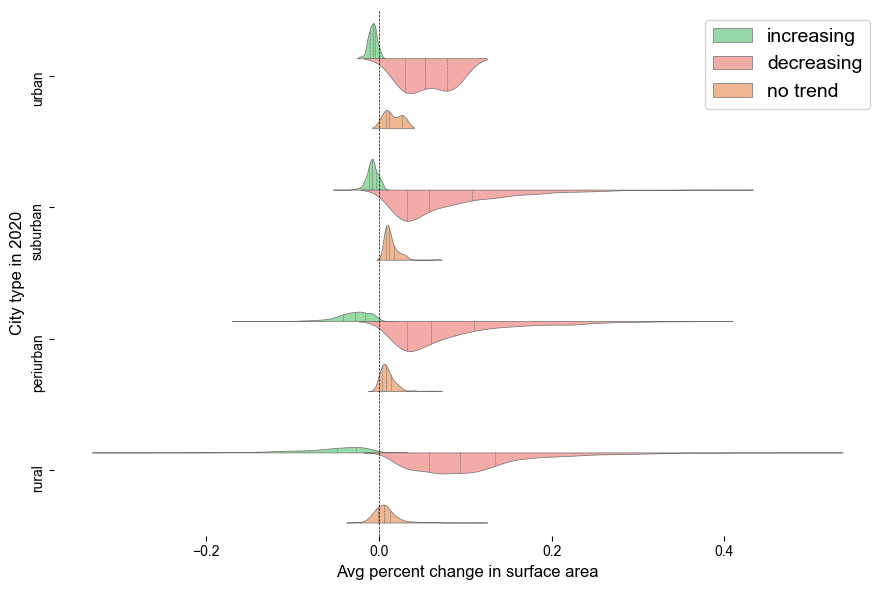

In [92]:
building_clean['avg_percent_change'] = building_clean[['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].mean(axis=1)
fig, ax = plt.subplots(figsize=(9, 6))
sns.violinplot(ax=ax, data = building_clean, y= 'city type', x= 'avg_percent_change', hue='future trend from SSP 2', split=True, inner="quart",
               order=['urban', 'suburban', 'periurban', 'rural'], palette = ['#8de5a1','#ff9f9b', '#ffb482'], linewidth=0.5)
ax.axvline(x = 0, linestyle = '--', linewidth = 0.5, color ='black') 
ax.set(frame_on=False)
# sns.set_style("whitegrid", {'axes.grid' : False})
plt.yticks(rotation=90, ha='right')
ax.legend(fontsize=14,)
ax.set_xlabel('Avg percent change in surface area',fontsize=12)
ax.set_ylabel('City type in 2020',fontsize=12)
sns.set_style("ticks")
fig.tight_layout()
plt.savefig(r"D:\Work\Box Sync\Quantify Infrastructure\Figures\avg_percent_building_change.png", transparent=True)
# plt.legend(loc='lower right')
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

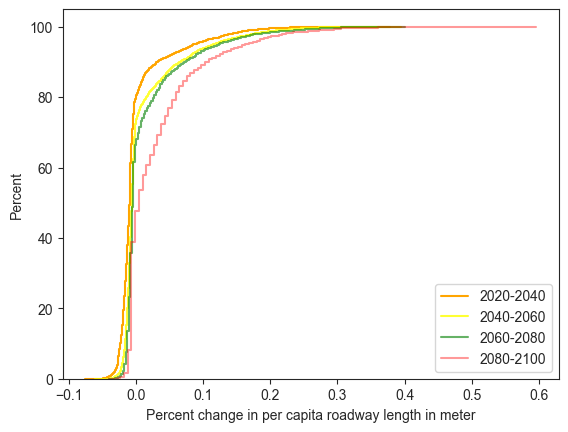

In [93]:
# roads_clean[roads_clean['per_cap_mass_at_2100'] < roads_clean['per_cap_mass_at_2020']]['per_cap_mass_at_2020'].describe()
data = building_clean[building_clean['city type'] == 'suburban']

stat_method = 'percent'
cumulative_method = True

sns.histplot(np.sort((data['per_cap_mass_at_2040'] - data['per_cap_mass_at_2020'])/data['per_cap_mass_at_2020']), alpha = 1.0, color= 'orange', element='step', fill=False, stat= stat_method, cumulative= cumulative_method)
sns.histplot(np.sort((data['per_cap_mass_at_2060'] - data['per_cap_mass_at_2040'])/data['per_cap_mass_at_2040']), alpha = 0.8, color= 'yellow', element='step', fill=False, stat= stat_method, cumulative= cumulative_method)
sns.histplot(np.sort((data['per_cap_mass_at_2080'] - data['per_cap_mass_at_2060'])/data['per_cap_mass_at_2060']), alpha = 0.6, color ='green', element='step', fill=False, stat= stat_method, cumulative= cumulative_method)
sns.histplot(np.sort((data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2080'])/data['per_cap_mass_at_2080']), alpha = 0.4, color ='red', element='step', fill=False, stat= stat_method, cumulative= cumulative_method)
plt.xlabel('Percent change in per capita roadway length in meter')
plt.legend(labels=['2020-2040', '2040-2060', '2060-2080', '2080-2100'])

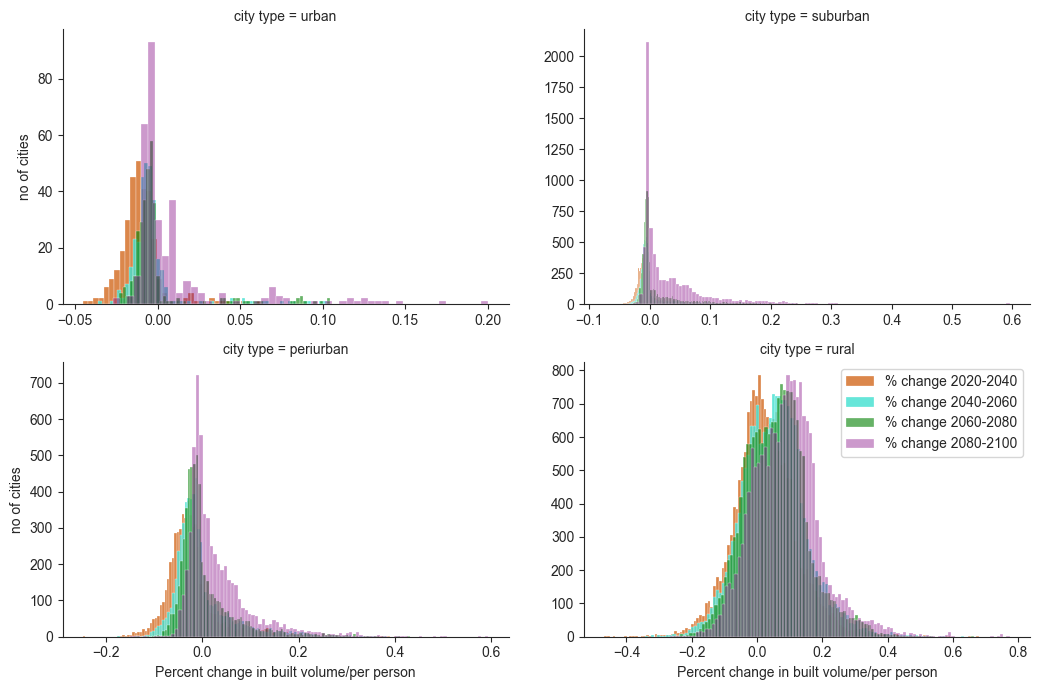

In [94]:
data = building_clean

data['percent change from 2020-2040'] = (data['per_cap_mass_at_2040'] - data['per_cap_mass_at_2020'])/data['per_cap_mass_at_2020']
data['percent change from 2040-2060'] = (data['per_cap_mass_at_2060'] - data['per_cap_mass_at_2040'])/data['per_cap_mass_at_2040']
data['percent change from 2060-2080'] = (data['per_cap_mass_at_2080'] - data['per_cap_mass_at_2060'])/data['per_cap_mass_at_2060']
data['percent change from 2080-2100'] = (data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2080'])/data['per_cap_mass_at_2080']
data['percent change from 2020-2100'] = (data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2020'])/data['per_cap_mass_at_2020']
data['percent change from 2020-2060'] = (data['per_cap_mass_at_2060'] - data['per_cap_mass_at_2020'])/data['per_cap_mass_at_2020']
data['percent change from 2060-2100'] = (data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2060'])/data['per_cap_mass_at_2060']

citytype_name = ['urban', 'suburban', 'periurban', 'rural']

# fig, axs = plt.subplots(nrows =2, ncols =2,  figsize=(7, 7))
g = sns.FacetGrid(data, col='city type', col_wrap=2, col_order = ['urban', 'suburban', 'periurban', 'rural'], 
                  sharex=False, sharey=False, margin_titles=False, height=3.5, aspect=1.5)
g.map(sns.histplot,'percent change from 2020-2040', alpha = 0.8, color= 'chocolate', linewidth=0.2)
g.map(sns.histplot,'percent change from 2040-2060', alpha = 0.8, color= 'Turquoise', linewidth=0.2)
g.map(sns.histplot,'percent change from 2060-2080', alpha = 0.6, color= 'green', linewidth=0.2)
g.map(sns.histplot,'percent change from 2080-2100', alpha = 0.4, color= 'purple', linewidth=0.2)
g.set_axis_labels("Percent change in built volume/per person", "no of cities")
plt.legend(labels=['% change 2020-2040', '% change 2040-2060', '% change 2060-2080', '% change 2080-2100'])

In [95]:
data.groupby('city type')[['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].max()

,percent change from 2020-2040,percent change from 2040-2060,percent change from 2060-2080,percent change from 2080-2100
city type,,,,
periurban,0.405207,0.407933,0.431520,0.594136
rural,0.679612,0.634921,0.663934,0.773913
suburban,0.378141,0.394456,0.400749,0.595450
urban,0.063388,0.102610,0.104398,0.200401


In [96]:
data.groupby('city type')[['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].min()

,percent change from 2020-2040,percent change from 2040-2060,percent change from 2060-2080,percent change from 2080-2100
city type,,,,
periurban,-0.248027,-0.176258,-0.137123,-0.150967
rural,-0.468361,-0.344713,-0.255186,-0.267654
suburban,-0.075609,-0.060797,-0.039597,-0.039361
urban,-0.045310,-0.036186,-0.023082,-0.027310


In [97]:
data.groupby('city type')[['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].mean()

,percent change from 2020-2040,percent change from 2040-2060,percent change from 2060-2080,percent change from 2080-2100
city type,,,,
periurban,-0.021502,-0.002798,0.006967,0.031962
rural,0.024177,0.051562,0.059143,0.090411
suburban,0.001077,0.010900,0.015829,0.033922
urban,-0.010478,-0.002805,-0.000196,0.009094


In [98]:
data.groupby('city type')[['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].quantile([0.5])*100

,,percent change from 2020-2040,percent change from 2040-2060,percent change from 2060-2080,percent change from 2080-2100
city type,,,,,
periurban,0.5,-3.090710,-1.783824,-1.166718,0.820684
rural,0.5,1.902214,5.084746,5.882353,8.985025
suburban,0.5,-0.928436,-0.547480,-0.366752,0.669725
urban,0.5,-1.132476,-0.611054,-0.538670,-0.238913


In [99]:
cols = ['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100','percent change from 2020-2060',
                           'percent change from 2060-2100','percent change from 2020-2100']
for col in cols:
    print(col, np.round((data[data[col] < 0].shape[0] / data.shape[0]), 2))

percent change from 2020-2040 0.57
percent change from 2040-2060 0.48
percent change from 2060-2080 0.44
percent change from 2080-2100 0.29
percent change from 2020-2060 0.51
percent change from 2060-2100 0.35
percent change from 2020-2100 0.42


c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\uttar\mi

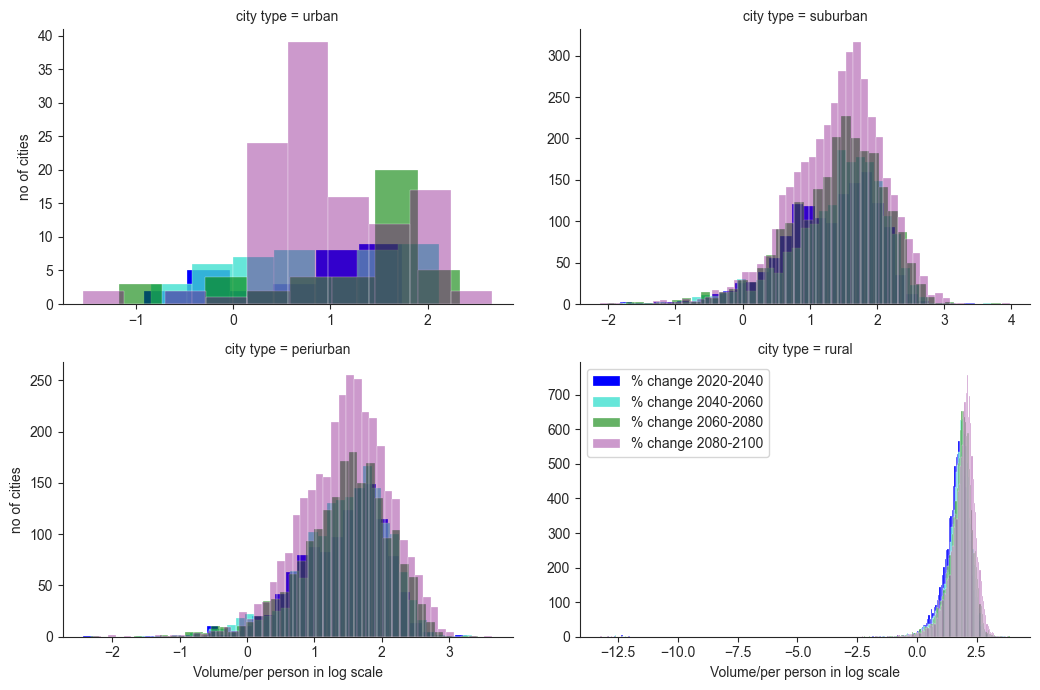

In [100]:
data['m3-change from 2020-2040'] = np.log10(data['per_cap_mass_at_2040'] - data['per_cap_mass_at_2020'])
data['m3-change from 2040-2060'] = np.log10(data['per_cap_mass_at_2060'] - data['per_cap_mass_at_2040'])
data['m3-change from 2060-2080'] = np.log10(data['per_cap_mass_at_2080'] - data['per_cap_mass_at_2060'])
data['m3-change from 2080-2100'] = np.log10(data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2080'])

citytype_name = ['urban', 'suburban', 'periurban', 'rural']

# fig, axs = plt.subplots(nrows =2, ncols =2,  figsize=(7, 7))
g = sns.FacetGrid(data, col='city type', col_wrap=2, col_order = ['urban', 'suburban', 'periurban', 'rural'], 
                  sharex=False, sharey=False, margin_titles=False, height=3.5, aspect=1.5)
g.map(sns.histplot,'m3-change from 2020-2040', alpha = 1.0, color= 'blue', linewidth=0.2)
g.map(sns.histplot,'m3-change from 2040-2060', alpha = 0.8, color= 'Turquoise', linewidth=0.2)
g.map(sns.histplot,'m3-change from 2060-2080', alpha = 0.6, color= 'green', linewidth=0.2)
g.map(sns.histplot,'m3-change from 2080-2100', alpha = 0.4, color= 'purple', linewidth=0.2)
g.set_axis_labels("Volume/per person in log scale", "no of cities")
plt.legend(labels=['% change 2020-2040', '% change 2040-2060', '% change 2060-2080', '% change 2080-2100'])

In [101]:
df_population[df_population['NAMELSAD'] == 'Fontenelle CDP'][[ 'ssp22030', 'ssp22040',  'ssp22050', 'ssp22060', 'ssp22070',  'ssp22080','ssp22090', 'ssp22100',  'ssp22020']]

,ssp22030,ssp22040,ssp22050,ssp22060,ssp22070,ssp22080,ssp22090,ssp22100,ssp22020
31547,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0


In [102]:
building_clean['percent change from 2020-2060'] = (building_clean['per_cap_mass_at_2060'] - building_clean['per_cap_mass_at_2020']) / building_clean['per_cap_mass_at_2020']
building_clean['percent change from 2060-2100'] = (building_clean['per_cap_mass_at_2100'] - building_clean['per_cap_mass_at_2060']) / building_clean['per_cap_mass_at_2060']
building_clean['percent change from 2020-2100'] = (building_clean['per_cap_mass_at_2100'] - building_clean['per_cap_mass_at_2020']) / building_clean['per_cap_mass_at_2020']

building_clean['per cap added from 2020-2030'] = (building_clean['per_cap_mass_at_2030'] - building_clean['per_cap_mass_at_2020'])
building_clean['per cap added from 2030-2040'] = (building_clean['per_cap_mass_at_2040'] - building_clean['per_cap_mass_at_2030'])
building_clean['per cap added from 2040-2050'] = (building_clean['per_cap_mass_at_2050'] - building_clean['per_cap_mass_at_2040'])
building_clean['per cap added from 2050-2060'] = (building_clean['per_cap_mass_at_2060'] - building_clean['per_cap_mass_at_2050'])
building_clean['per cap added from 2060-2070'] = (building_clean['per_cap_mass_at_2070'] - building_clean['per_cap_mass_at_2060'])
building_clean['per cap added from 2070-2080'] = (building_clean['per_cap_mass_at_2080'] - building_clean['per_cap_mass_at_2070'])
building_clean['per cap added from 2080-2090'] = (building_clean['per_cap_mass_at_2090'] - building_clean['per_cap_mass_at_2080'])
building_clean['per cap added from 2090-2100'] = (building_clean['per_cap_mass_at_2100'] - building_clean['per_cap_mass_at_2090'])

building_clean_sub = building_clean.assign(**building_clean[['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040', 'per_cap_mass_at_2050', 
'per_cap_mass_at_2060', 'per_cap_mass_at_2070', 'per_cap_mass_at_2080', 'per_cap_mass_at_2090', 'per_cap_mass_at_2100']].sub(building_clean['per_cap_mass_at_2020'], axis=0).add_prefix('sub_'))

In [103]:
building_clean_sub[['per cap added from 2020-2030', 'per cap added from 2030-2040','sub_per_cap_mass_at_2030', 'sub_per_cap_mass_at_2040']]

,per cap added from 2020-2030,per cap added from 2030-2040,sub_per_cap_mass_at_2030,sub_per_cap_mass_at_2040
0,-86.300625,-62.287473,-86.300625,-148.588097
1,-52.651130,-48.579514,-52.651130,-101.230644
2,-5.674055,7.651617,-5.674055,1.977561
3,-1.656614,-0.217248,-1.656614,-1.873862
4,-38.627767,-21.192258,-38.627767,-59.820025
...,...,...,...,...
30539,-51.971627,-18.938246,-51.971627,-70.909873
30540,-24.639924,-11.914002,-24.639924,-36.553927
30541,-46.535409,-34.051453,-46.535409,-80.586862
30542,-54.859480,-49.414990,-54.859480,-104.274469


In [104]:
# building_clean_sub.filter(regex='sub*').columns

In [105]:
# building_clean[building_clean['CensusPop_20'] > 500000][['NAMELSAD', 'ssp22020', 'ssp22040', 'ssp22050','ssp22070',  'ssp22080', 'ssp22100']]

In [106]:
# building_clean[building_clean['CensusPop_20'] > 500000].sort_values(by ='percent change from 2020-2100')[['NAMELSAD',  'per_cap_mass_at_2020', 
#                                     'per_cap_mass_at_2030',  'per_cap_mass_at_2040',  'per_cap_mass_at_2060', 
#                                     'per_cap_mass_at_2070',  'per_cap_mass_at_2080',  'per_cap_mass_at_2090',  'per_cap_mass_at_2100' ]]
# [['per cap added from 2020-2030', 'per cap added from 2050-2060', 'per cap added from 2060-2070', 'per cap added from 2070-2080', 'per cap added from 2080-2090', 'per cap added from 2090-2100']]

### Temporal shift from zero base

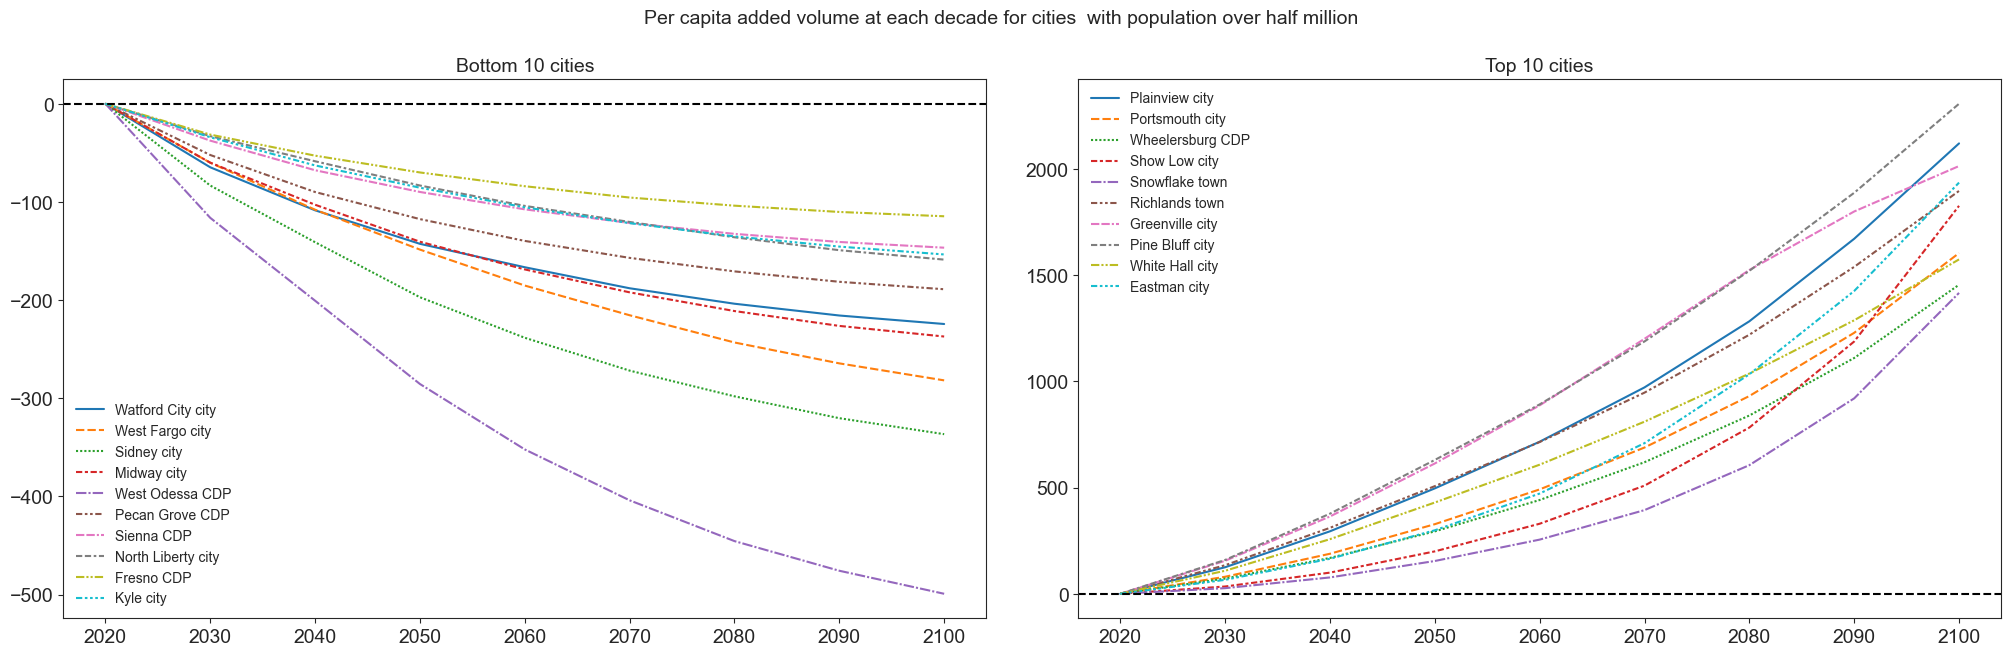

In [107]:
building_df_sorted = building_clean_sub[building_clean_sub['CensusPop_20'] > 5000].sort_values(by ='percent change from 2020-2100')[['NAMELSAD', 
        'sub_per_cap_mass_at_2020', 'sub_per_cap_mass_at_2030',
       'sub_per_cap_mass_at_2040', 'sub_per_cap_mass_at_2050',
       'sub_per_cap_mass_at_2060', 'sub_per_cap_mass_at_2070',
       'sub_per_cap_mass_at_2080', 'sub_per_cap_mass_at_2090',
       'sub_per_cap_mass_at_2100']]

# building_df_sorted = building_clean[building_clean['CensusPop_20'] > 500000].sort_values(by ='percent change from 2020-2100')[['NAMELSAD', 'per_cap_mass_at_2020', 
#                                     'per_cap_mass_at_2030',  'per_cap_mass_at_2040',  'per_cap_mass_at_2050',  'per_cap_mass_at_2060', 
#                                     'per_cap_mass_at_2070',  'per_cap_mass_at_2080',  'per_cap_mass_at_2090',  'per_cap_mass_at_2100',]]

lower_10 = building_df_sorted.head(10).set_index('NAMELSAD') 
upper_10 = building_df_sorted.tail(10).set_index('NAMELSAD') 

df_lineplot = [lower_10.T, upper_10.T]
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(25,7))
fig.suptitle('Per capita added volume at each decade for cities  with population over half million', fontsize= 14)
axes[0].set_title('Bottom 10 cities', fontsize= 14)
axes[1].set_title('Top 10 cities', fontsize= 14)
for ax , df in zip(axes, df_lineplot):
    sns.lineplot(ax= ax, data=df, legend = True)
    # sns.move_legend(ax, loc = 2, bbox_to_anchor=(1, 1))
    ax.axhline(y=0, color = 'black', alpha = 1,linestyle= '--')
    ax.set_xticks(range(len(df)), ['2020', '2030','2040','2050','2060','2070','2080','2090', '2100']) #,rotation = 30)
    ax.tick_params(labelsize= 14)
    ax.legend(frameon=False)
plt.rc('legend',fontsize=14) 
plt.subplots_adjust(wspace=0.1, hspace=0.1)

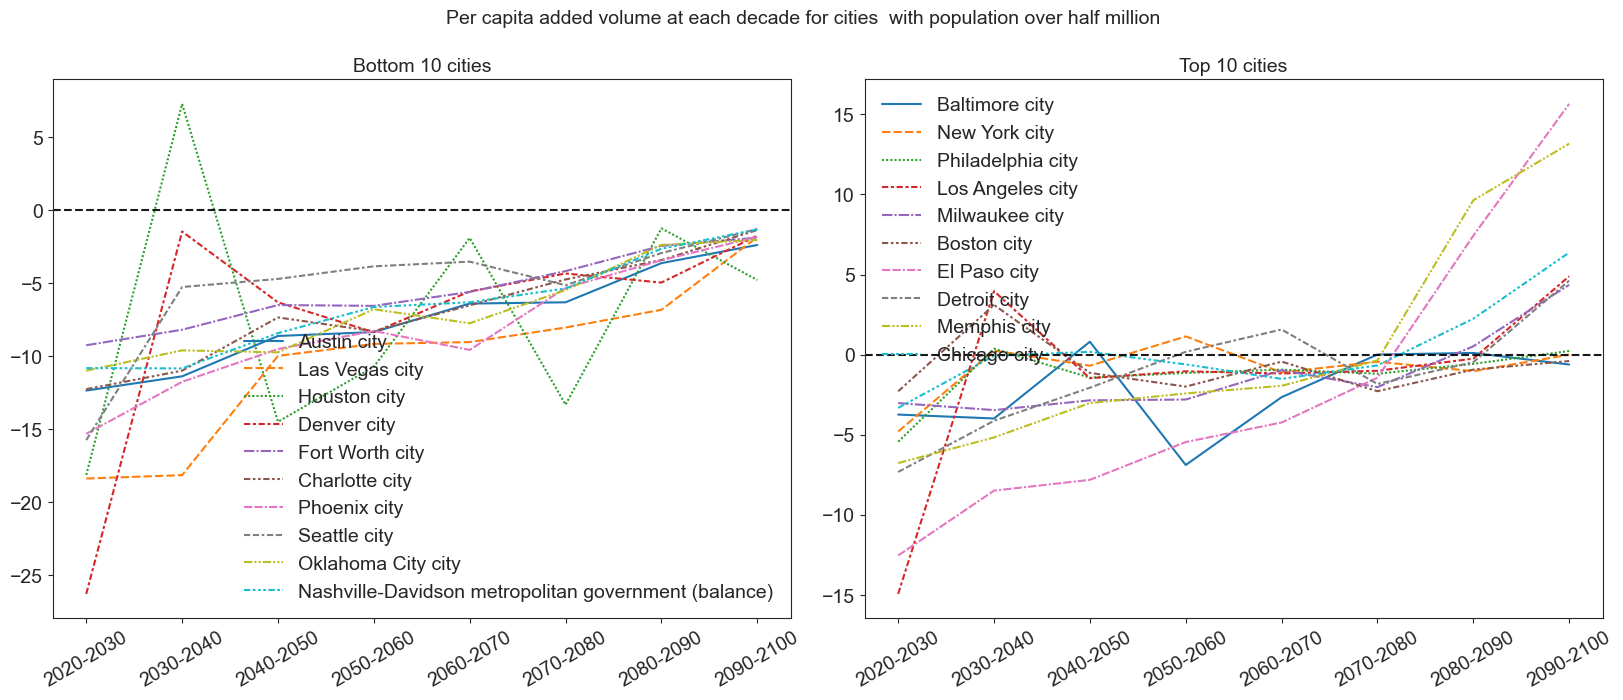

In [108]:
building_df_sorted = building_clean[building_clean['CensusPop_20'] > 500000].sort_values(by ='percent change from 2020-2100')[['NAMELSAD', 
        'per cap added from 2020-2030', 'per cap added from 2030-2040',
       'per cap added from 2040-2050', 'per cap added from 2050-2060', 'per cap added from 2060-2070', 'per cap added from 2070-2080',
       'per cap added from 2080-2090', 'per cap added from 2090-2100']]


lower_10 = building_df_sorted.head(10).set_index('NAMELSAD') 
upper_10 = building_df_sorted.tail(10).set_index('NAMELSAD') 

df_lineplot = [lower_10.T, upper_10.T]
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(20,7))
fig.suptitle('Per capita added volume at each decade for cities  with population over half million', fontsize= 14)
axes[0].set_title('Bottom 10 cities', fontsize= 14)
axes[1].set_title('Top 10 cities', fontsize= 14)
for ax , df in zip(axes, df_lineplot):
    sns.lineplot(ax= ax, data=df, legend = 'brief')
    # sns.move_legend(ax, loc = 2, bbox_to_anchor=(1, 1))
    ax.axhline(y=0, color = 'black', alpha = 0.9,linestyle= '--')
    ax.set_xticks(range(len(df)), ['2020-2030', '2030-2040','2040-2050','2050-2060','2060-2070','2070-2080','2080-2090','2090-2100',],rotation = 30)
    ax.tick_params(labelsize= 14)
    ax.legend(frameon=False)
plt.rc('legend',fontsize=14) 
plt.subplots_adjust(wspace=0.1, hspace=0.1)

In [109]:
# import matplotlib.pyplot as plt
# fig, ax = plt.subplots(figsize=(10, 4))
# building_clean[building_clean['city type'] == 'urban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040', 'per_cap_mass_at_2050', 'per_cap_mass_at_2060', 'per_cap_mass_at_2070', 
#                                                         'per_cap_mass_at_2080', 'per_cap_mass_at_2090', 'per_cap_mass_at_2100', ]].sum().plot() #sort_values(by ='percent change from 2040-2060')
# building_clean[building_clean['city type'] == 'suburban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040', 'per_cap_mass_at_2050', 'per_cap_mass_at_2060', 'per_cap_mass_at_2070', 
#                                                         'per_cap_mass_at_2080', 'per_cap_mass_at_2090', 'per_cap_mass_at_2100', ]].sum().plot()
# building_clean[building_clean['city type'] == 'periurban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040', 'per_cap_mass_at_2050', 'per_cap_mass_at_2060', 'per_cap_mass_at_2070', 
#                                                         'per_cap_mass_at_2080', 'per_cap_mass_at_2090', 'per_cap_mass_at_2100', ]].sum().plot()
# building_clean[building_clean['city type'] == 'rural'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040', 'per_cap_mass_at_2050', 'per_cap_mass_at_2060', 'per_cap_mass_at_2070', 
#                                                         'per_cap_mass_at_2080', 'per_cap_mass_at_2090', 'per_cap_mass_at_2100', ]].sum().plot()

### Plot Maps

In [110]:
# # Import cartographic base maps: Cartographic boundary for plotting
US_counties_cb = gpd.read_file(r'D:\Work\Box Sync\Trends_all states\Maps_2020\cb_2020_us_county_5m.zip') # tl_2020_us_county
US_states_cb = gpd.read_file(r'D:\Work\Box Sync\Trends_all states\Maps_2020\cb_2020_us_state_5m.zip')  # tl_2020_us_state
# source: https://gis.stackexchange.com/questions/141580/which-projection-is-best-for-mapping-the-contiguous-united-states
US_states_cb = US_states_cb.to_crs('EPSG:9311')
US_counties_cb = US_counties_cb.to_crs('EPSG:9311')

In [111]:
# Function to categorize values based on quartile range
def categorize_by_quartiles(grouped_df, target_column):
    # Calculate quartile values
    Q1 = grouped_df.quantile(0.25)
    Q3 = grouped_df.quantile(0.75)

    # Categorize values based on quartiles
    def categorize_value(value):
        if value < Q1:
            return 'Pressurized'
        elif value > Q3:
            return 'Oversized'
        else:
            return 'Balanced'

    # Apply categorization to target_column
    return target_column.apply(categorize_value)

In [112]:
df_map =building_clean_sub.copy()

print(df_map.shape)

df_map = df_map.to_crs('EPSG:9311')
df_map.columns

# Group data by 'group_column' before calculating quartiles
grouped = df_map.groupby('city type')

# Create a new column based on quartile values of values_column within each group
df_map['utilization_2020'] = grouped['per_cap_mass_at_2020'].transform(lambda x: categorize_by_quartiles(x, x))

# # Apply the same quartile thresholds to categorize target_column within each group
df_map['utilization_2040'] = grouped['per_cap_mass_at_2020'].transform(lambda x: categorize_by_quartiles(x, df_map['per_cap_mass_at_2040']))
df_map['utilization_2060'] = grouped['per_cap_mass_at_2020'].transform(lambda x: categorize_by_quartiles(x, df_map['per_cap_mass_at_2060']))
df_map['utilization_2080'] = grouped['per_cap_mass_at_2020'].transform(lambda x: categorize_by_quartiles(x, df_map['per_cap_mass_at_2080']))
df_map['utilization_2100'] = grouped['per_cap_mass_at_2020'].transform(lambda x: categorize_by_quartiles(x, df_map['per_cap_mass_at_2100']))

(30544, 163)


In [113]:
df_population['CensusPop_20'].sum(), df_population['ssp12050'].sum(), df_population['ssp22050'].sum(), df_population['ssp42050'].sum()

(249755152, 311681615.0, 305168689.0, 288189999.0)

In [114]:
df_population['CensusPop_20'].sum()/0.759, df_population['ssp32050'].sum()/0.759, df_population['ssp22050'].sum()/0.759, df_population['ssp42050'].sum()/0.759

(329058171.2779974, 336237777.95617384, 402066783.9262187, 379696968.3794466)

In [115]:
# col_names = ['per_cap_mass_at_2020', 'per_cap_mass_at_2060',  'per_cap_mass_at_2100']
# fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(24, 6))
# for ax, col in zip(axs, col_names):
#     df_map_regions = df_map.groupby(['REGION', 'city type'])[col].quantile([0.25, 0.5, 0.75])
#     # Create a box plot of the quantile values for each selected column
#     df_map_regions.unstack().T.plot(kind='box',vert=True, ax=ax)
#     # # ax.title('Box plot of Quantile Values by Group')
#     ax.set_ylabel('volume (cum/per)')
#     ax.hlines(y=900, xmin=0, xmax=16, linewidth=1, color='r')
#     # Rotating X-axis labels
#     ax.tick_params(axis='x', labelrotation = 90)
#     # plt.xlabel('Group')
#     ax.set_ylim([0, 1550])
#     ax.grid(False)


In [116]:
df_map.groupby(['city type'])[['per_cap_mass_at_2020', 'per_cap_mass_at_2080']].describe().round(2)

per_cap_mass_at_2020                                           \
                         count    mean      std     min     25%     50%   
city type                                                                 
periurban               5700.0  825.09   774.14   28.49  542.02  720.67   
rural                  17647.0  918.94  2865.33   12.43  584.14  766.96   
suburban                6885.0  921.70   661.40   51.86  635.68  837.14   
urban                    312.0  659.93   359.58  167.62  458.66  593.51   

                              per_cap_mass_at_2080                            \
               75%        max                count     mean      std     min   
city type                                                                      
periurban   959.50   30589.29               5700.0   825.36   816.61   22.47   
rural      1024.31  341691.09              17647.0  1061.79  2219.63    8.72   
suburban   1072.84   28832.58               6885.0   953.23   755.92   54.83   
urban       741.36    3651.69                312.0   654.03   365.97  162.97   

                                               
              25%     50%      75%        max  
city type                                      
periurban  509.86  692.50   958.70   27152.00  
rural      626.26  876.94  1227.75  243048.29  
suburban   647.08  855.59  1103.65   31496.50  
urban      449.93  578.61   739.67    3552.67

In [117]:
df_map[df_map['per_cap_mass_at_2020'] > 10000][['State', 'NAMELSAD', 'CensusPop_20','city type', 'per_cap_mass_at_2020', 'per_cap_mass_at_2060', 'per_cap_mass_at_2100']].sort_values(by='per_cap_mass_at_2020')

,State,NAMELSAD,CensusPop_20,city type,per_cap_mass_at_2020,per_cap_mass_at_2060,per_cap_mass_at_2100
8357,19.0,Riverdale city,379.0,suburban,11414.714915,11213.495893,11108.626574
4096,12.0,Weeki Wachee city,16.0,periurban,12245.261029,12114.677177,12856.705784
20259,39.0,Cuyahoga Heights village,573.0,suburban,12403.186593,13693.691556,15517.523838
920,4.0,Roosevelt CDP,26.0,rural,13513.586425,13000.107774,13617.537498
20247,39.0,Holiday City village,48.0,rural,14541.346405,17449.615686,23266.154248
26031,48.0,Thompsons town,156.0,rural,14609.435923,10639.009398,9132.455639
4310,12.0,Medley town,1056.0,suburban,14679.274424,14304.269230,14177.152074
3629,8.0,North Washington CDP,733.0,periurban,14994.278164,13157.504107,12433.385330
22034,41.0,Biggs Junction CDP,5.0,rural,16033.421176,20075.709777,26767.613036
686,4.0,Alamo Lake CDP,4.0,rural,16124.858824,21499.811765,21499.811765


In [118]:
# df_map.groupby(['city type'])[['per_cap_mass_at_2020']].describe().round(2)

In [119]:
# df_map.columns[120:]

In [120]:
# df_map.groupby(['REGION','city type', ])[['median_income', 'weighted_HU_density_sqmi']].quantile([0.25, 0.5, 0.75]).round(2)

### Age of buildings

In [121]:
# df_map[['State', 'CensusPop_20', 'ssp22020', 'ssp22060', 'city type',' !!Total:', 'weighted_HU_density_sqmi','weighted_avg_age', 'NAMELSAD','volume_Res_2020','surface_Res_at_2030','per_cap_mass_at_2020','per_cap_mass_at_2030', 'per cap added from 2020-2030',
#        'per cap added from 2030-2040', 'per cap added from 2040-2050','per cap added from 2050-2060',]]#.sort_values(by='per cap added from 2020-2030',)

In [122]:
# Define a function that applies another function to each row of the DataFrame
def get_weighted_age(df, function, age_column, current_stock, stock_at_t):
    if stock_at_t[-4:] == '2030':
          t = float(stock_at_t[-4:]) - 2024
    else:
        t = 10

    # Apply function to each row
    result = df.apply(lambda row: function( row[age_column], row[current_stock],row[stock_at_t],t), axis=1)
    return result

# EQUATION: (((df_map['surface_Res_at_2030'] - df_map['volume_Res_2020'])*8 + df_map['volume_Res_2020']*(df_map['weighted_avg_age']+16)) / ((df_map['surface_Res_at_2030'] - df_map['volume_Res_2020']) + df_map['volume_Res_2020']))
def weighted_age_at_t(age_column, current_stock, stock_at_t, t):   
        # print(t)          
        return (((stock_at_t - current_stock)*t/2) + (current_stock*(age_column + t))) / ((stock_at_t - current_stock) + current_stock)

# Apply some_function to each row of the DataFrame
df_map['weighted_age_2030'] = get_weighted_age(df_map, weighted_age_at_t, age_column= 'weighted_avg_age', current_stock = 'volume_Res_2020', stock_at_t= 'surface_Res_at_2030')
df_map['weighted_age_2040'] = get_weighted_age(df_map, weighted_age_at_t, age_column= 'weighted_age_2030', current_stock = 'surface_Res_at_2030', stock_at_t= 'surface_Res_at_2040')
df_map['weighted_age_2050'] = get_weighted_age(df_map, weighted_age_at_t, age_column= 'weighted_age_2040', current_stock = 'surface_Res_at_2040', stock_at_t= 'surface_Res_at_2050')
df_map['weighted_age_2060'] = get_weighted_age(df_map, weighted_age_at_t, age_column= 'weighted_age_2050', current_stock = 'surface_Res_at_2050', stock_at_t= 'surface_Res_at_2060')
df_map['weighted_age_2070'] = get_weighted_age(df_map, weighted_age_at_t, age_column= 'weighted_age_2060', current_stock = 'surface_Res_at_2060', stock_at_t= 'surface_Res_at_2070')
df_map['weighted_age_2080'] = get_weighted_age(df_map, weighted_age_at_t, age_column= 'weighted_age_2070', current_stock = 'surface_Res_at_2070', stock_at_t= 'surface_Res_at_2080')
df_map['weighted_age_2090'] = get_weighted_age(df_map, weighted_age_at_t, age_column= 'weighted_age_2080', current_stock = 'surface_Res_at_2080', stock_at_t= 'surface_Res_at_2090')
df_map['weighted_age_2100'] = get_weighted_age(df_map, weighted_age_at_t, age_column= 'weighted_age_2090', current_stock = 'surface_Res_at_2090', stock_at_t= 'surface_Res_at_2100')

In [123]:
df_map[df_map['weighted_age_2040'] > 61].shape[0] / df_map.shape[0], df_map[df_map['weighted_age_2050'] > 61].shape[0] / df_map.shape[0], df_map[df_map['weighted_age_2060'] > 61].shape[0] / df_map.shape[0]

(0.6315806705081194, 0.8056901519119958, 0.9148114195914091)

In [124]:
df_map[df_map['weighted_age_2060'] > 105].shape[0] / df_map.shape[0]

0.07752750130958617

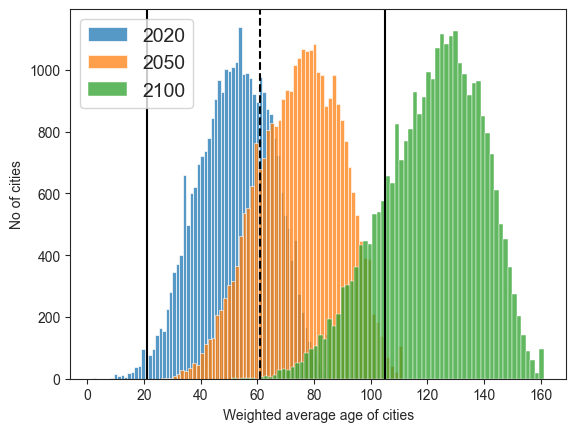

In [125]:
sns.histplot(df_map['weighted_avg_age'])
sns.histplot(df_map['weighted_age_2050'])
sns.histplot(df_map['weighted_age_2100'])
plt.ylabel('No of cities')
plt.xlabel('Weighted average age of cities') # derived from age of housing units
plt.legend(labels=['2020','2050', '2100'])
plt.axvline(21, color='black')
plt.axvline(61, color='black', linestyle = '--')
plt.axvline(105, color='black')
sns.set_theme(rc={'figure.figsize':(9,7)})

import matplotlib
from matplotlib import rc

# matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['savefig.transparent'] = True
plt.savefig(r'D:\Work\Box Sync\Quantify Infrastructure\Figures\weighted_age_buildings0.png', dpi = 300, bbox_inches='tight')

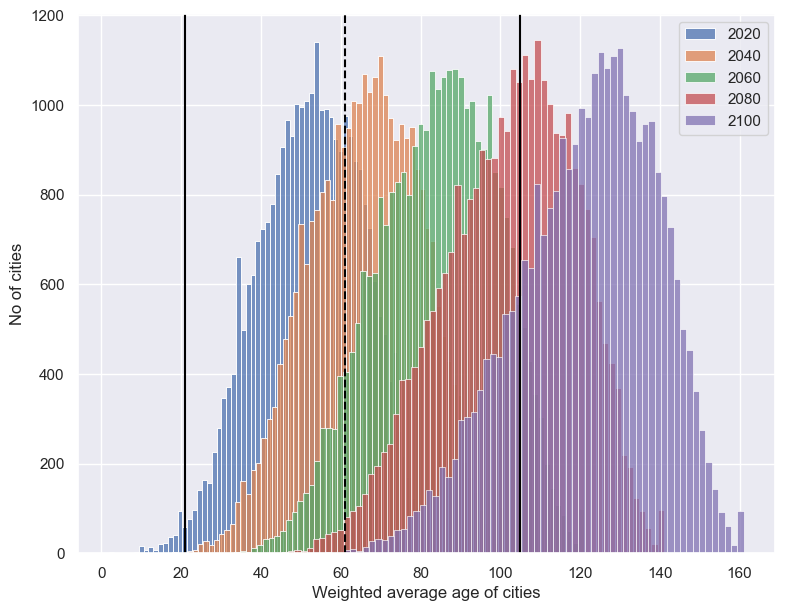

In [126]:
sns.histplot(df_map['weighted_avg_age'])
sns.histplot(df_map['weighted_age_2040'])
sns.histplot(df_map['weighted_age_2060'])
sns.histplot(df_map['weighted_age_2080'])
sns.histplot(df_map['weighted_age_2100'])
plt.ylabel('No of cities')
plt.xlabel('Weighted average age of cities') # derived from age of housing units
plt.legend(labels=['2020','2040', '2060', '2080', '2100'])
plt.axvline(21, color='black')
plt.axvline(61, color='black', linestyle = '--')
plt.axvline(105, color='black')
sns.set_theme(rc={'figure.figsize':(10,6)})

import matplotlib
from matplotlib import rc

# matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['savefig.transparent'] = True
plt.savefig(r'D:\Work\Box Sync\Quantify Infrastructure\Figures\weighted_age_buildings.png', dpi = 300, bbox_inches='tight')

In [127]:
df_map.groupby(['city type'])[['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040',
       'per_cap_mass_at_2050', 'per_cap_mass_at_2060', 'per_cap_mass_at_2070',
       'per_cap_mass_at_2080', 'per_cap_mass_at_2090', 'per_cap_mass_at_2100', 'avg_HU_size_Res_sqm',]].quantile([.25, .5, .75])

per_cap_mass_at_2020  per_cap_mass_at_2030  \
city type                                                    
periurban 0.25            542.023907            529.272183   
          0.50            720.667551            706.180825   
          0.75            959.495297            947.876914   
rural     0.25            584.143624            583.150115   
          0.50            766.957681            769.229156   
          0.75           1024.314747           1030.633193   
suburban  0.25            635.677780            634.585947   
          0.50            837.142490            834.139160   
          0.75           1072.843656           1071.844312   
urban     0.25            458.660387            453.412297   
          0.50            593.514478            586.581077   
          0.75            741.360150            733.795161   

                per_cap_mass_at_2040  per_cap_mass_at_2050  \
city type                                                    
periurban 0.25            524.519289            521.998216   
          0.50            700.248254            694.098676   
          0.75            942.747964            945.651951   
rural     0.25            590.432307            600.118467   
          0.50            783.620439            806.857738   
          0.75           1058.874690           1098.436090   
suburban  0.25            636.634879            639.536479   
          0.50            834.878099            839.497822   
          0.75           1076.922190           1084.062193   
urban     0.25            455.873256            454.821294   
          0.50            587.943619            589.737852   
          0.75            733.707991            734.020412   

                per_cap_mass_at_2060  per_cap_mass_at_2070  \
city type                                                    
periurban 0.25            517.248389            512.539925   
          0.50            692.447876            690.456835   
          0.75            947.238772            951.217266   
rural     0.25            607.059171            614.660019   
          0.50            825.461187            846.303301   
          0.75           1132.889627           1173.656637   
suburban  0.25            640.756581            644.398861   
          0.50            843.241051            848.236067   
          0.75           1088.984244           1092.370096   
urban     0.25            452.214940            451.693679   
          0.50            585.618953            581.439274   
          0.75            736.485579            735.615679   

                per_cap_mass_at_2080  per_cap_mass_at_2090  \
city type                                                    
periurban 0.25            509.856262            511.797329   
          0.50            692.500717            699.117409   
          0.75            958.695854            979.151019   
rural     0.25            626.256101            641.649890   
          0.50            876.936745            911.230189   
          0.75           1227.749362           1293.531822   
suburban  0.25            647.083166            652.990381   
          0.50            855.594565            864.288624   
          0.75           1103.649293           1119.503607   
urban     0.25            449.925867            449.431262   
          0.50            578.611800            579.259377   
          0.75            739.673472            745.923072   

                per_cap_mass_at_2100  avg_HU_size_Res_sqm  
city type                                                  
periurban 0.25            516.504891          1288.150031  
          0.50            708.351996          1725.770224  
          0.75           1005.881219          2241.166098  
rural     0.25            660.590556          1219.467681  
          0.50            955.720457          1567.814730  
          0.75           1379.093298          1998.523967  
suburban  0.25            659.898827          1496.459577  


In [128]:
df_map[df_map['city type']=='suburban'][['GEOID', 'REGION','city type',  'NAMELSAD','CensusPop_20','weighted_avg_age', 'per_cap_mass_at_2020']]

,GEOID,REGION,city type,NAMELSAD,CensusPop_20,weighted_avg_age,per_cap_mass_at_2020
3,0176872,South,suburban,Trinity town,2526.0,38.508,859.545385
10,0103076,South,suburban,Auburn city,76143.0,32.061,641.312194
12,0107912,South,suburban,Boaz city,10107.0,46.921,993.227599
14,0168280,South,suburban,Sardis City town,1814.0,39.203,755.693229
17,0151600,South,suburban,Moulton city,3398.0,47.679,936.624148
...,...,...,...,...,...,...,...
30427,5625620,West,suburban,Evanston city,11747.0,44.348,817.065617
30467,5615400,West,suburban,Clearview Acres CDP,758.0,33.316,541.612168
30481,5629300,West,suburban,Fox Farm-College CDP,3876.0,41.913,1015.117594
30526,5671350,West,suburban,Sleepy Hollow CDP,1227.0,34.524,286.855787


In [129]:
df_map[df_map['city type']=='periurban'][['GEOID', 'REGION','city type',  'NAMELSAD','CensusPop_20','weighted_avg_age', 'per_cap_mass_at_2020']]

,GEOID,REGION,city type,NAMELSAD,CensusPop_20,weighted_avg_age,per_cap_mass_at_2020
6,0132704,South,periurban,Haleyville city,4361.0,51.543,1164.010385
11,0177304,South,periurban,Tuskegee city,9395.0,50.109,633.806232
16,0177880,South,periurban,Union Springs city,3358.0,47.389,752.284078
21,0101396,South,periurban,Allgood town,548.0,44.487,420.019958
31,0142472,South,periurban,Level Plains town,1825.0,34.218,704.970009
...,...,...,...,...,...,...,...
30509,5656700,West,periurban,North Rock Springs CDP,2439.0,34.172,914.096349
30520,5663800,West,periurban,Ranchettes CDP,6199.0,37.362,784.886632
30521,5664400,West,periurban,Red Butte CDP,410.0,70.530,801.335552
30528,5671800,West,periurban,South Greeley CDP,4733.0,39.099,650.840665


In [130]:
# df_map[(df_map['city type']=='periurban') & (df_map['weighted_avg_age'] > 50)].shape, df_map[(df_map['city type']=='suburban') & (df_map['weighted_avg_age'] > 50)].shape

In [131]:
# df_map[df_map['State']!=0].groupby(['State'])[['weighted_avg_age', 'per_cap_mass_at_2020']].min().head(50)

In [132]:
df_map[['GEOID', 'NAMELSAD','CensusPop_20', 'label', 'future trend from SSP 2', 'volume_Res_2020', 'per_cap_mass_at_2020','per_cap_mass_at_2060','surface_Res_at_2060',
        'weighted_avg_age', 'weighted_age_2040', 'weighted_age_2060', ]].sort_values('weighted_avg_age').dropna().tail(10)

,GEOID,NAMELSAD,CensusPop_20,label,future trend from SSP 2,volume_Res_2020,per_cap_mass_at_2020,per_cap_mass_at_2060,surface_Res_at_2060,weighted_avg_age,weighted_age_2040,weighted_age_2060
3352,0815550,Cokedale town,127.0,3 slowly depopulating,decreasing,74472.752941,586.399629,670.925702,74472.752941,85.0,101.000000,121.000000
3366,0807025,Black Hawk city,127.0,5 slowly increasing,increasing,205201.423529,1615.759240,1416.750155,226680.024780,85.0,95.326096,111.675713
15032,3002050,Antelope CDP,74.0,6 moderately increasing,increasing,67394.192157,910.732326,607.727725,94805.525029,85.0,85.815050,91.559819
28830,5314520,Conway CDP,87.0,4 fluctuating,no trend,76567.882353,880.090602,830.408008,80549.576781,85.0,97.659184,116.258195
2241,0608744,Bucks Lake CDP,22.0,7 highly increasing,decreasing,30190.388235,1372.290374,2744.580749,30190.388235,85.0,101.000000,121.000000
15431,3101465,Anoka village,10.0,4 fluctuating,decreasing,5588.533333,558.853333,698.566667,5588.533333,85.0,101.000000,121.000000
24922,4644940,New Holland CDP,77.0,4 fluctuating,increasing,84026.568627,1091.254138,1110.834693,85534.271335,85.0,101.000000,118.955281
24901,4633380,Kaylor CDP,30.0,2 moderately depopulating,decreasing,122685.560784,4089.518693,4543.909659,122685.560784,85.0,101.000000,121.000000
24843,4670740,Wetonka town,16.0,7 highly increasing,no trend,9946.305882,621.644118,639.204107,10227.265717,85.0,100.038796,118.114009
3106,0678176,Tennant CDP,63.0,4 fluctuating,decreasing,66637.239216,1057.733956,1306.612534,66637.239216,85.0,101.000000,121.000000


In [133]:
df_map.filter(regex='ssp*').columns
# -------------

Index(['ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070',
       'ssp22080', 'ssp22090', 'ssp22100', 'ssp12020', 'ssp12030', 'ssp12040',
       'ssp12050', 'ssp12060', 'ssp12070', 'ssp12080', 'ssp12090', 'ssp12100',
       'ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060', 'ssp42070',
       'ssp42080', 'ssp42090', 'ssp42100', 'per_cap__nonRes_mass_at_2020',
       'per_cap__total_mass_at_2020', 'per_cap_mass_at_2020',
       'surface_Res_gross_2020', 'per_cap_mass_at_2030',
       'per_cap_mass_at_2040', 'per_cap_mass_at_2050', 'per_cap_mass_at_2060',
       'per_cap_mass_at_2070', 'per_cap_mass_at_2080', 'per_cap_mass_at_2090',
       'per_cap_mass_at_2100', 'sub_per_cap_mass_at_2020',
       'sub_per_cap_mass_at_2030', 'sub_per_cap_mass_at_2040',
       'sub_per_cap_mass_at_2050', 'sub_per_cap_mass_at_2060',
       'sub_per_cap_mass_at_2070', 'sub_per_cap_mass_at_2080',
       'sub_per_cap_mass_at_2090', 'sub_per_cap_mass_at_2100'],
      dtype='object'

In [134]:
df_map[df_map['weighted_age_2060'] > 105].shape, df_map[df_map['weighted_age_2080'] > 105].shape

((2368, 176), (14343, 176))

In [135]:
df_check = df_map[['STATEFP', 'GEOID','NAMELSAD', 'NAME_x', 'city type', 'REGION', 'per_cap_mass_at_2020','volume_Res_2020', 'surface_Res_at_2030', 'surface_Res_at_2040', 'surface_Res_at_2050',
       'surface_Res_at_2060', 'surface_Res_at_2070', 'surface_Res_at_2080', 'surface_Res_at_2090', 'surface_Res_at_2100', 'per cap added from 2020-2030',
       'per cap added from 2030-2040', 'per cap added from 2040-2050', 'per cap added from 2050-2060', 'per cap added from 2060-2070',
       'per cap added from 2070-2080', 'per cap added from 2080-2090', 'per cap added from 2090-2100', 'per_cap_mass_at_2080', 'per_cap_mass_at_2090','per_cap_mass_at_2100',
       'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070',
       'ssp22080', 'ssp22090', 'ssp22100',]]

df_check['City'] = df_check['NAME_x'] + "," + df_check['STATEFP']

In [136]:
df_check[['per cap added from 2020-2030','per cap added from 2060-2070', 'per cap added from 2070-2080', 'per cap added from 2080-2090', 'per cap added from 2090-2100', 
          'per_cap_mass_at_2020','volume_Res_2020']].quantile([.5,.995, 1])

,per cap added from 2020-2030,per cap added from 2060-2070,per cap added from 2070-2080,per cap added from 2080-2090,per cap added from 2090-2100,per_cap_mass_at_2020,volume_Res_2020
0.500,-4.428336,0.699545,7.067668,13.880842,19.150950,772.825113,7.149115e+05
0.995,167.214030,278.148151,332.858292,399.771875,481.429901,3766.760486,1.456957e+08
1.000,2645.675090,4709.793116,3415.282966,4361.053633,6691.903259,341691.085869,2.760422e+09


In [137]:
df_check[df_check['per cap added from 2020-2030'] < 1000].sort_values('per_cap_mass_at_2020').tail(100)[['per cap added from 2020-2030','per cap added from 2030-2040', 'per cap added from 2040-2050', 'per cap added from 2050-2060', 'per cap added from 2060-2070',
       'per cap added from 2070-2080', 'per cap added from 2080-2090', 'per cap added from 2090-2100']]

,per cap added from 2020-2030,per cap added from 2030-2040,per cap added from 2040-2050,per cap added from 2050-2060,per cap added from 2060-2070,per cap added from 2070-2080,per cap added from 2080-2090,per cap added from 2090-2100
15822,-54.965299,201.322142,220.963327,0.000000,0.000000,243.626232,0.000000,2.699642e+02
24330,-14.835969,-3.331083,-3.667547,-22.096001,-1.950997,2.839157,29.106808,5.939362e+01
19147,-323.528965,-232.612577,-194.887451,-165.322474,-127.468967,-113.611418,-80.833529,-3.937241e+01
27109,-186.815989,-130.127222,-104.600863,-93.840074,-52.234941,33.742704,97.668048,1.253304e+02
18742,-68.631671,-23.459739,-32.306743,-29.019599,-34.862898,-18.665458,-21.853150,-1.308413e+01
...,...,...,...,...,...,...,...,...
23443,-940.171962,-578.333169,-215.426976,-575.387176,-178.401020,-262.648885,62.766492,7.275958e-12
16153,-2558.639672,-1219.514568,-1823.313705,-1549.784900,-1072.090259,-731.034729,-905.038159,-5.015787e+02
1892,-3631.531738,-2407.617845,-1788.253823,-1404.529239,-1001.908309,-472.948923,1.641576,6.910111e+02
1983,-4838.916312,-3183.327545,-2287.138764,-1616.265866,-1460.456724,-453.444660,244.581589,4.935307e+02


In [138]:
import plotly.graph_objects as go
long_df = df_check[df_check['per_cap_mass_at_2020'] < 1000].sort_values('per_cap_mass_at_2020').tail(100)

fig = go.Figure()

fig.add_trace(go.Barpolar(
    r=[1000]* len(long_df),
    theta = long_df['City'].values,
    name='',
    marker_color='white'
))

fig.add_trace(go.Barpolar(  
    r=long_df['per_cap_mass_at_2020'].values,
    theta = long_df['City'].values,
    name='Base RBUV',
    marker_color='grey'
))

fig.add_trace(go.Barpolar(
    r=long_df['per cap added from 2020-2030'].values,
    theta =long_df['City'].values,
    name='added from 2020-2030',
    marker_color='olive'
))
fig.add_trace(go.Barpolar(
    r=long_df['per cap added from 2030-2040'].values,
    theta = long_df['City'].values,
    name="added from 2030-2040",
    marker_color='chocolate'
))
fig.add_trace(go.Barpolar(
    r=long_df['per cap added from 2040-2050'].values,
    theta = long_df['City'].values,
    name="added from 2040-2050",
    marker_color='coral'
))
fig.add_trace(go.Barpolar(
    r=long_df['per cap added from 2050-2060'].values,
    theta = long_df['City'].values,
    name='added from 2050-2060',
    marker_color='goldenrod'
))
fig.add_trace(go.Barpolar(
    r=long_df['per cap added from 2060-2070'].values,
    theta =long_df['City'].values,
    name="added from 2060-2070",
    marker_color='orchid'
))
fig.add_trace(go.Barpolar(
    r=long_df['per cap added from 2070-2080'].values,
    theta = long_df['City'].values,
    name="added from 2070-2080",
    marker_color='lightpink'
))
fig.add_trace(go.Barpolar(
    r=long_df['per cap added from 2080-2090'].values,
    theta =long_df['City'].values,
    name="added from 2080-2090",
    marker_color='greenyellow'
))
fig.add_trace(go.Barpolar(
    r=long_df['per cap added from 2090-2100'].values,
    theta = long_df['City'].values,
    name="added from 2090-2100",
    marker_color='yellow'
))
fig.update_layout(
    title='Temporal change in per capita RBUV (m$3$)',
    width =1000,
    height=1000,
    font_size=14,
    legend_font_size=16,
    # polar_angularaxis_tickangle=40,
    # polar_radialaxis_ticksuffix='%',
    polar_angularaxis_rotation=0,
    # polar_angularaxis_ticklabelstep=2,

)
fig.show()

In [139]:
import plotly.graph_objects as go
long_df = df_check[df_check['per_cap_mass_at_2020'] < 1000].sort_values('per_cap_mass_at_2020').head(100)

fig = go.Figure()

fig.add_trace(go.Barpolar(
    r=[50]* len(long_df),
    theta = long_df['City'].values,
    name='',
    marker_color='white'
))

fig.add_trace(go.Barpolar(  
    r=long_df['per_cap_mass_at_2020'].values,
    theta = long_df['City'].values,
    name='Base RBUV',
    marker_color='grey'
))

fig.add_trace(go.Barpolar(
    r=long_df['per cap added from 2020-2030'].values,
    theta =long_df['City'].values,
    name='added from 2020-2030',
    marker_color='olive'
))
fig.add_trace(go.Barpolar(
    r=long_df['per cap added from 2030-2040'].values,
    theta = long_df['City'].values,
    name="added from 2030-2040",
    marker_color='chocolate'
))
fig.add_trace(go.Barpolar(
    r=long_df['per cap added from 2040-2050'].values,
    theta = long_df['City'].values,
    name="added from 2040-2050",
    marker_color='coral'
))
fig.add_trace(go.Barpolar(
    r=long_df['per cap added from 2050-2060'].values,
    theta = long_df['City'].values,
    name='added from 2050-2060',
    marker_color='goldenrod'
))
fig.add_trace(go.Barpolar(
    r=long_df['per cap added from 2060-2070'].values,
    theta =long_df['City'].values,
    name="added from 2060-2070",
    marker_color='orchid'
))
fig.add_trace(go.Barpolar(
    r=long_df['per cap added from 2070-2080'].values,
    theta = long_df['City'].values,
    name="added from 2070-2080",
    marker_color='lightpink'
))
fig.add_trace(go.Barpolar(
    r=long_df['per cap added from 2080-2090'].values,
    theta =long_df['City'].values,
    name="added from 2080-2090",
    marker_color='greenyellow'
))
fig.add_trace(go.Barpolar(
    r=long_df['per cap added from 2090-2100'].values,
    theta = long_df['City'].values,
    name="added from 2090-2100",
    marker_color='yellow'
))
fig.update_layout(
    title='Temporal change in per capita RBUV (m$3$)',
    width =1000,
    height=1000,
    font_size=14,
    legend_font_size=16,
    # polar_angularaxis_tickangle=40,
    # polar_radialaxis_ticksuffix='%',
    polar_angularaxis_rotation=0,
    # polar_angularaxis_ticklabelstep=2,

)
fig.show()

In [140]:
# df_map.columns[75:120]

In [141]:
# df_check.sort_values(by =['surface_Res_at_2100'])[['GEOID','NAMELSAD', 'city type',  'weighted_HU_density_sqmi', 'HU_density_sqmi_at_2100','surface_Res_2020','surface_Res_at_2100', 'per_cap_mass_at_2020', 'per_cap_mass_at_2100','CensusPop_20', 'ssp22020', 'ssp22100',]]

In [142]:
# df_check.sort_values(by =['volume_Res_2020'])[['GEOID','NAMELSAD', 'city type',  'weighted_HU_density_sqmi','HU_density_sqmi_at_2100', 'volume_Res_2020','surface_Res_at_2030',
#                                                  'per_cap_mass_at_2020', 'per_cap_mass_at_2100','CensusPop_20', 'ssp22020', 'ssp22100',]]

In [143]:
# sns.scatterplot(df_check, x = 'CensusPop_20', y = 'volume_Res_2020')

In [144]:
# data = df_check[df_check['city type']== 'urban']

# ax= sns.scatterplot(data, x = 'ssp22100', y = 'surface_Res_at_2100',), sns.scatterplot(data, x = 'ssp22050', y = 'surface_Res_at_2050',), sns.scatterplot(data, x = 'CensusPop_20', y = 'volume_Res_2020')

# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D
# colors = ['blue', 'orange', 'green']
# lines = [Line2D([0], [0], color=c, linewidth=3, ) for c in colors]
# labels = ['2100', '2030', '2020']
# plt.legend(lines, labels)
# # sns.relplot(data=data, x = 'ssp22050', y = 'surface_Res_at_2050', col="city type", kind="scatter"), sns.relplot(data=data,x = 'CensusPop_20', y = 'surface_Res_2020',col="city type", kind="scatter")
# # fig = px.scatter(data, x = 'ssp22050', y = 'surface_Res_at_2050',)
# # fig.show()

In [145]:
# data = df_check[df_check['city type']== 'suburban']

# ax= sns.scatterplot(data, x = 'ssp22100', y = 'surface_Res_at_2100',), sns.scatterplot(data, x = 'ssp22050', y = 'surface_Res_at_2050',), sns.scatterplot(data, x = 'CensusPop_20', y = 'volume_Res_2020')

# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D
# colors = ['blue', 'orange', 'green']
# lines = [Line2D([0], [0], color=c, linewidth=3, ) for c in colors]
# labels = ['2100', '2030', '2020']
# plt.legend(lines, labels)

In [190]:
# sns.scatterplot(df_check[df_check['city type']== 'urban'], x = 'ssp22100', y = 'surface_Res_at_2100', hue= 'REGION')

### Add landuse data from 2019

In [147]:
# Do not include landuse data about Hawaii
df_nlcd = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\GEE_NLCD_landuse\LandCoverbyCity19.csv')
df_nlcd['GEOID'] = df_nlcd['GEOID'].astype(str).str.rjust(7,'0')

column_names = ['Open_water', 'Perennial_ice_snow', 'Developed_open_space','Developed_low_intensity', 'Developed_medium_intensity',
       'Developed_high_intensity', 'Barren_land', 'Deciduous_forest', 'Evergreen_forest', 'Mixed_forest', 'Dwarf_scrub', 'Shrub_scrub',
       'Grassland_herbaceous', 'Sedge_herbaceous', 'Lichens', 'Moss', 'Pasture_hay', 'Cultivated_crops', 'Woody_wetland', 'EmergentherbaceousWetlands']

df_nlcd[column_names] = df_nlcd[column_names].div(df_nlcd[column_names].sum(axis=1), axis=0).multiply(100)
df_nlcd = df_nlcd.fillna(0)

df_nlcd['veg_wetland'] = df_nlcd[['Dwarf_scrub', 'Shrub_scrub', 'Grassland_herbaceous', 'Sedge_herbaceous', 'Lichens', 'Moss',
       'Pasture_hay', 'Cultivated_crops', 'Woody_wetland', 'EmergentherbaceousWetlands', 'Perennial_ice_snow']].sum(axis=1)
df_nlcd['forest'] = df_nlcd[['Deciduous_forest','Evergreen_forest', 'Mixed_forest']].sum(axis=1)

In [148]:
BVPC_df = df_map.merge(df_nlcd[['GEOID', 'Open_water','veg_wetland', 'forest', 'Barren_land', 'Developed_open_space', 
'Developed_low_intensity', 'Developed_medium_intensity', 'Developed_high_intensity']], on ='GEOID')

BVPC_df['otherLU'] = BVPC_df[['Open_water','veg_wetland', 'forest', 'Barren_land']].sum(axis=1)
BVPC_df['developedLU'] = BVPC_df[['Developed_open_space','Developed_low_intensity', 'Developed_medium_intensity', 'Developed_high_intensity']].sum(axis=1)
BVPC_df['developedLU_2'] = BVPC_df[['Developed_medium_intensity', 'Developed_high_intensity']].sum(axis=1)

In [149]:
BVPC_df[(BVPC_df['per_cap_mass_at_2020'] < 75)][['State', 'CensusPop_20', 'ssp22060', 'city type',' !!Total:', 'weighted_HU_density_sqmi','weighted_avg_age', 'weighted_age_2060', 'NAMELSAD', 
                                                 'per_cap_mass_at_2020', 'per_cap_mass_at_2060', 'surface_2020', 'volume_Res_2020', 'otherLU','developedLU_2',
       'developedLU','REGION',]].sort_values(by ='per_cap_mass_at_2020' )

,State,CensusPop_20,ssp22060,city type,!!Total:,weighted_HU_density_sqmi,weighted_avg_age,weighted_age_2060,NAMELSAD,per_cap_mass_at_2020,per_cap_mass_at_2060,surface_2020,volume_Res_2020,otherLU,developedLU_2,developedLU,REGION
5772,15.0,419.0,611.852481,rural,176,11.501121,32.418,62.295352,Wainiha CDP,12.425720,9.744136,2326.878431,5206.376471,0.000000,0.000000,0.000000,West
28237,51.0,367.0,788.716903,periurban,285,731.164945,23.992,42.760067,Kincora CDP,28.487931,23.556421,4268.945098,10455.070588,60.104570,25.043521,39.895430,South
23973,42.0,920.0,692.713039,suburban,6,12.866236,NaN,NaN,University of Pittsburgh Bradford CDP,51.856969,68.843307,47593.129412,47708.411765,9.889733,34.281070,90.110267,Northeast
3851,9.0,3639.0,4161.958225,suburban,11,314.656505,NaN,NaN,Quinnipiac University CDP,55.664979,55.057177,136804.945098,202564.858824,14.588018,48.205765,85.411982,Northeast
2436,6.0,156.0,193.884702,rural,45,42.568658,NaN,NaN,El Monte Mobile Village CDP,61.551835,54.132370,3840.517647,9602.086275,4.841394,75.685752,95.158606,West
2713,6.0,1154.0,1498.118407,periurban,537,150.946991,65.325,87.704359,Lompico CDP,66.349832,61.523786,30605.796078,76567.705882,70.825361,0.017309,29.174639,West
22676,42.0,193.0,228.812991,rural,202,146.101017,70.103,100.404686,Mount Gretna borough,71.229645,64.239647,5496.729412,13747.321569,29.652581,0.915673,70.347419,Northeast


In [150]:
BVPC_df[(BVPC_df['developedLU'] ==100)][['State', 'CensusPop_20', 'city type','weighted_HU_density_sqmi','weighted_avg_age', 'NAMELSAD', 'ALAND','surface_2020', 'volume_Res_2020','per_cap_mass_at_2020', 'per_cap_mass_at_2060', 
                                         'otherLU','developedLU_2',
       'developedLU','median_income']].sort_values(by ='per_cap_mass_at_2020' ).tail(20)

,State,CensusPop_20,city type,weighted_HU_density_sqmi,weighted_avg_age,NAMELSAD,ALAND,surface_2020,volume_Res_2020,per_cap_mass_at_2020,per_cap_mass_at_2060,otherLU,developedLU_2,developedLU,median_income
14226,29.0,860.0,suburban,2005.113097,63.201,Edmundson city,710384,1.761586e+05,1.173084e+06,1364.051341,1349.717534,0.0,65.458775,100.0,42813.0
2257,6.0,1776.0,periurban,678.921077,52.937,Calwa CDP,1470052,4.207159e+05,2.427279e+06,1366.711303,1301.162074,0.0,70.929905,100.0,45458.0
10211,21.0,397.0,suburban,2598.693291,75.324,Kingsley city,187167,5.486931e+04,5.492631e+05,1383.534163,1360.055917,0.0,16.806333,100.0,92031.0
14293,29.0,4750.0,suburban,1621.204248,57.119,Rock Hill city,2838756,6.476323e+05,6.578058e+06,1384.854301,1366.585848,0.0,29.225680,100.0,75895.0
3100,6.0,3997.0,periurban,1196.384527,64.386,Tarpey Village CDP,2043494,7.522059e+05,5.604725e+06,1402.232836,1302.751630,0.0,52.323447,100.0,54750.0
14364,29.0,8233.0,suburban,2688.545696,61.963,Brentwood city,5039465,1.363941e+06,1.174702e+07,1426.821251,1407.606086,0.0,52.855298,100.0,80486.0
13862,29.0,2018.0,suburban,422.118082,63.774,Warson Woods city,1470854,3.120422e+05,3.019227e+06,1496.148060,1470.415242,0.0,17.173746,100.0,166042.0
14050,29.0,508.0,suburban,584.079609,49.275,Crystal Lake Park city,251491,7.078353e+04,7.696234e+05,1515.006639,1546.825307,0.0,6.425158,100.0,129063.0
14493,29.0,366.0,suburban,1520.017296,62.470,Oakview village,452515,6.871810e+04,5.584089e+05,1525.707511,1494.301757,0.0,14.756929,100.0,72500.0
13896,29.0,128.0,periurban,1529.044070,68.221,Oaks village,234694,2.666898e+04,1.988127e+05,1553.224081,1449.887633,0.0,5.327267,100.0,89688.0


In [151]:
np.max(BVPC_df['surface_2020'] *100/ BVPC_df['ALAND'])

50.47149870320609

In [152]:
np.max(BVPC_df['volume_Res_2020'] *100/ (3*BVPC_df['ALAND']))

209.52828778869255

In [153]:
28000/3, 573*100/9333

(9333.333333333334, 6.139504982320797)

In [154]:
# # y1 = BVPC_df[BVPC_df['NAMELSAD'] == 'New York city'][['volume_Res_2020','surface_Res_at_2030', 'surface_Res_at_2040', 'surface_Res_at_2050', 'surface_Res_at_2060', 'surface_Res_at_2070', 'surface_Res_at_2080', 'surface_Res_at_2090', 'surface_Res_at_2100']].values.T
# # y2 = BVPC_df[BVPC_df['NAMELSAD'] == 'Chicago city'][['volume_Res_2020','surface_Res_at_2030', 'surface_Res_at_2040', 'surface_Res_at_2050', 'surface_Res_at_2060', 'surface_Res_at_2070', 'surface_Res_at_2080', 'surface_Res_at_2090', 'surface_Res_at_2100']].values.T
# # y3 = BVPC_df[BVPC_df['NAMELSAD'] == 'Houston city'][['volume_Res_2020','surface_Res_at_2030', 'surface_Res_at_2040', 'surface_Res_at_2050', 'surface_Res_at_2060', 'surface_Res_at_2070', 'surface_Res_at_2080', 'surface_Res_at_2090', 'surface_Res_at_2100']].values.T
# # y4 = BVPC_df[BVPC_df['NAMELSAD'] == 'Los Angeles city'][['volume_Res_2020','surface_Res_at_2030', 'surface_Res_at_2040', 'surface_Res_at_2050', 'surface_Res_at_2060', 'surface_Res_at_2070', 'surface_Res_at_2080', 'surface_Res_at_2090', 'surface_Res_at_2100']].values.T
# y5 = BVPC_df[BVPC_df['GEOID'] == '1724582'][['volume_Res_2020','surface_Res_at_2030', 'surface_Res_at_2040', 'surface_Res_at_2050', 'surface_Res_at_2060', 'surface_Res_at_2070', 'surface_Res_at_2080', 'surface_Res_at_2090', 'surface_Res_at_2100']].values.T


# x = np.array([1,2,3,4,5,6,7,8,9])


# plt.title("Line graph")
# # plt.plot(x, y1, color="red")
# # plt.plot(x, y2, color="green")
# # plt.plot(x, y3, color="blue")
# # plt.plot(x, y4, color="purple")
# plt.plot(x, y5, color="pink")

plt.show()

In [155]:
# BVPC_df[BVPC_df['NAMELSAD'] == 'Evanston city'][['State', 'CensusPop_20', 'ssp22060', 'city type',' !!Total:', 'weighted_HU_density_sqmi','weighted_avg_age', 'weighted_age_2060', 'NAMELSAD', 'per_cap_mass_at_2020', 'per_cap_mass_at_2060', 
#                                              'utilization_2020', 'utilization_2060','utilization_2100', 'otherLU','developedLU_2', 'developedLU','REGION','median_income']]

In [156]:
# BVPC_df[BVPC_df['NAMELSAD'] == 'Evanston city'][['State', 'NAMELSAD', 'per_cap_mass_at_2020','per_cap_mass_at_2060','per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2100','percent change from 2020-2100', 'developedLU_2', 'developedLU',]]

In [157]:
df_map.groupby(['city type'])[['per_cap_mass_at_2020',  'weighted_HU_density_sqmi']].quantile([0.75, 0.90, 0.99, 0.995,])

per_cap_mass_at_2020  weighted_HU_density_sqmi
city type                                                      
periurban 0.750            959.495297                746.844116
          0.900           1256.087399               1504.917354
          0.990           2694.613038               3153.850351
          0.995           3458.753623               3527.175298
rural     0.750           1024.314747                 32.648646
          0.900           1372.084757                 66.065502
          0.990           2869.344945                296.507007
          0.995           3891.131913                547.000211
suburban  0.750           1072.843656               1419.115506
          0.900           1341.100795               2175.208195
          0.990           2653.988872               3584.913915
          0.995           3428.166093               3794.483262
urban     0.750            741.360150               6775.948549
          0.900            972.623780               9265.590469
          0.990           2061.556378              25712.412704
          0.995           2621.534214              28247.101846

In [158]:
BVPC_df[(BVPC_df['developedLU_2'] > 95)][['State', 'CensusPop_20', 'ssp22060', 'city type',' !!Total:', 'weighted_HU_density_sqmi','weighted_avg_age', 'weighted_age_2060', 'NAMELSAD', 'per_cap_mass_at_2020',]].sort_values(by ='per_cap_mass_at_2020' ).tail(20)

,State,CensusPop_20,ssp22060,city type,!!Total:,weighted_HU_density_sqmi,weighted_avg_age,weighted_age_2060,NAMELSAD,per_cap_mass_at_2020
2463,6.0,61983.0,76871.410190,urban,14975,4538.000365,66.232,88.034753,Florence-Graham CDP,374.826656
12022,26.0,28433.0,29635.365410,urban,8911,4362.118473,74.284,107.199609,Hamtramck city,379.949385
7205,17.0,85268.0,98104.868330,urban,25836,4788.504940,76.689,102.372887,Cicero town,387.684435
16406,34.0,5132.0,6119.656392,urban,1798,6282.766293,72.870,95.724469,Ampere North CDP,392.910544
1883,6.0,88083.0,109229.884100,urban,31578,7684.241353,54.552,79.156924,Hawthorne city,394.371121
3185,6.0,33913.0,42059.134720,urban,10990,6560.006038,64.073,86.263195,Westmont CDP,408.148017
2015,6.0,33559.0,41619.996320,urban,9468,5271.725640,65.117,87.267020,Bell city,412.941885
16706,34.0,4730.0,5303.004771,urban,1859,5411.628374,63.174,91.604994,Silver Lake CDP,456.283564
7164,17.0,57250.0,65861.737800,urban,21037,5731.383840,75.784,101.079444,Berwyn city,463.475080
11569,25.0,81045.0,114542.118400,urban,36269,10186.116198,68.824,82.438903,Somerville city,473.842604


In [159]:
BVPC_df[(BVPC_df['developedLU_2'] > 50)& (BVPC_df['Developed_high_intensity'] > 5)][['State', 'city type',' !!Total:', 'weighted_HU_density_sqmi','weighted_avg_age', 'weighted_age_2060', 'NAMELSAD', 'per_cap_mass_at_2020', 'per_cap_mass_at_2060', 
                                          'per_cap_mass_at_2100','Developed_low_intensity', 'Developed_medium_intensity', 'Developed_high_intensity','REGION',]].sort_values(by =['per_cap_mass_at_2020'])

,State,city type,!!Total:,weighted_HU_density_sqmi,weighted_avg_age,weighted_age_2060,NAMELSAD,per_cap_mass_at_2020,per_cap_mass_at_2060,per_cap_mass_at_2100,Developed_low_intensity,Developed_medium_intensity,Developed_high_intensity,REGION
2436,6.0,rural,45,42.568658,NaN,NaN,El Monte Mobile Village CDP,61.551835,54.132370,53.242097,18.492323,60.058311,15.627440,West
3860,9.0,suburban,1,685.696172,NaN,NaN,Sacred Heart University CDP,147.054164,145.143322,146.026267,12.460637,53.062906,29.013208,Northeast
18231,36.0,suburban,10,566.955420,NaN,NaN,Marist College CDP,154.080010,153.243100,155.205557,15.621584,32.684854,35.466672,Northeast
11300,24.0,urban,3562,26105.057604,49.885,65.844454,Friendship Heights Village CDP,167.621899,163.775796,161.634192,7.217699,44.189705,46.933318,South
3501,8.0,periurban,441,20.944496,45.422,63.338098,Aetna Estates CDP,186.802925,160.739758,151.454869,7.085384,78.312238,6.521790,West
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3358,8.0,rural,11,1513.587889,56.750,77.340665,Lakeside town,19913.137010,16228.066424,15356.473507,14.005538,30.028923,28.284531,West
7124,17.0,periurban,213,786.570811,71.697,99.309978,Bedford Park village,21119.177852,20360.898410,20605.120729,8.110514,18.174512,62.815923,Midwest
16153,34.0,rural,26,538.354622,45.878,74.243307,Teterboro borough,51192.557570,44041.304725,40831.562890,8.269360,29.295895,48.911013,Northeast
1892,6.0,rural,78,14.596991,28.565,61.220521,Vernon city,75660.194595,66428.261948,65646.057423,0.651884,7.748248,91.432793,West


In [160]:
BVPC_df['State_name'] = BVPC_df['NAME_y'].str.split(', ').str[1]

In [161]:
BVPC_df['weighted_HU_density_sqmi'].describe()

count    30544.000000
mean       402.453100
std        957.209693
min          0.000000
25%         10.849760
50%         42.721781
75%        361.056782
max      30707.800203
Name: weighted_HU_density_sqmi, dtype: float64

In [162]:
BVPC_df.columns[170:]

Index(['weighted_age_2050', 'weighted_age_2060', 'weighted_age_2070',
       'weighted_age_2080', 'weighted_age_2090', 'weighted_age_2100',
       'Open_water', 'veg_wetland', 'forest', 'Barren_land',
       'Developed_open_space', 'Developed_low_intensity',
       'Developed_medium_intensity', 'Developed_high_intensity', 'otherLU',
       'developedLU', 'developedLU_2', 'State_name'],
      dtype='object')

In [163]:
BVPC_df[(BVPC_df['per_cap_mass_at_2020'] > 10000) & (BVPC_df['weighted_HU_density_sqmi'] < 1002.453)][['STATEFP','State_name', 'NAMELSAD', 'CensusPop_20','city type', 'weighted_HU_density_sqmi',
                                                                                                'per_cap_mass_at_2020', 'Developed_high_intensity','developedLU',
                                                                                                #  'developedLU_2'
                                                                                                 ]].sort_values(by='per_cap_mass_at_2020')

,STATEFP,State_name,NAMELSAD,CensusPop_20,city type,weighted_HU_density_sqmi,per_cap_mass_at_2020,Developed_high_intensity,developedLU
8357,19,Iowa,Riverdale city,379.0,suburban,399.537257,11414.714915,21.720146,53.369603
4096,12,NaN,Weeki Wachee city,16.0,periurban,232.566405,12245.261029,3.453674,28.425606
20259,39,Ohio,Cuyahoga Heights village,573.0,suburban,356.044709,12403.186593,32.052150,71.516229
920,04,Arizona,Roosevelt CDP,26.0,rural,4.030562,13513.586425,0.374060,8.000005
20247,39,Ohio,Holiday City village,48.0,rural,25.941122,14541.346405,15.600696,41.264048
26031,48,Texas,Thompsons town,156.0,rural,36.373976,14609.435923,2.762251,10.679877
4310,12,Florida,Medley town,1056.0,suburban,280.913869,14679.274424,49.062429,77.054632
3629,08,Colorado,North Washington CDP,733.0,periurban,223.308579,14994.278164,45.689069,96.638908
22034,41,Oregon,Biggs Junction CDP,5.0,rural,1.098816,16033.421176,1.847141,22.033356
686,04,Arizona,Alamo Lake CDP,4.0,rural,0.734954,16124.858824,0.003413,0.675276


In [164]:
BVPC_df['State_name'].unique()

array(['Alabama', 'Arizona', 'Arkansas', nan, 'California', 'Colorado',
       'Connecticut', 'Delaware', 'District of Columbia', 'Florida',
       'Village of Islands village', 'Georgia', 'Hawaii', 'Idaho',
       'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
       'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota',
       'Tennessee', 'Moore County metropolitan government', 'Texas',
       'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia',
       'Wisconsin', 'Wyoming'], dtype=object)

In [165]:
BVPC_df[BVPC_df['CensusPop_20']>10000].groupby(['city type', 'STATEFP',])['CensusPop_20'].sum().tail(31)

city type  STATEFP
urban      04           180587.0
           06         12207753.0
           08           846644.0
           09           539201.0
           10            70898.0
           11           689545.0
           12          2283678.0
           13           498715.0
           15           402570.0
           17          3159424.0
           19            74828.0
           22           527504.0
           23            68408.0
           24           891479.0
           25          2089974.0
           26           667544.0
           27           741481.0
           29           301578.0
           32           227641.0
           34          1920625.0
           36         10459972.0
           39           746675.0
           41           652503.0
           42          2323824.0
           44           289121.0
           48          3625620.0
           49           199723.0
           50            44743.0
           51           542291.0
           53           

In [166]:
BVPC_df['per_cap_mass_at_2020'].quantile([0.75, 0.90, 0.99, 0.995, 0.998, 0.999])

0.750    1023.563843
0.900    1336.437183
0.990    2800.365315
0.995    3766.760486
0.998    5433.224460
0.999    8579.331581
Name: per_cap_mass_at_2020, dtype: float64

In [167]:
BVPC_df['Developed_high_intensity'].quantile([0.75, 0.90, 0.99, 0.995, 0.998, 0.999])

0.750     4.709863
0.900     9.004727
0.990    26.349103
0.995    33.876670
0.998    46.927313
0.999    53.863782
Name: Developed_high_intensity, dtype: float64

In [168]:
BVPC_df['developedLU'].quantile([0.75, 0.90, 0.99, 0.995, 0.998, 0.999])

0.750     66.398835
0.900     83.705445
0.990     99.859029
0.995    100.000000
0.998    100.000000
0.999    100.000000
Name: developedLU, dtype: float64

In [169]:
BVPC_df[(BVPC_df['Developed_high_intensity'] > 53)& (BVPC_df['per_cap_mass_at_2020'] >= 3766)][['State', 'NAMELSAD', 'per_cap_mass_at_2020', 'city type','CensusPop_20', 'Developed_high_intensity','developedLU']].sort_values(by =['per_cap_mass_at_2020','developedLU',])

,State,NAMELSAD,per_cap_mass_at_2020,city type,CensusPop_20,Developed_high_intensity,developedLU
16632,34.0,North Beach Haven CDP,4068.413907,suburban,2198.0,73.277237,89.462587
16481,34.0,Diamond Beach CDP,6791.151376,suburban,203.0,54.889886,84.455347
7124,17.0,Bedford Park village,21119.177852,periurban,602.0,62.815923,90.448501
1892,6.0,Vernon city,75660.194595,rural,222.0,91.432793,99.860776


In [170]:
BVPC_df[(BVPC_df['per_cap_mass_at_2020'] >= 10000)][['State', 'NAMELSAD', 'per_cap_mass_at_2020', 'city type','CensusPop_20', 'Developed_high_intensity','developedLU']].sort_values(by =['per_cap_mass_at_2020'])

,State,NAMELSAD,per_cap_mass_at_2020,city type,CensusPop_20,Developed_high_intensity,developedLU
8357,19.0,Riverdale city,11414.714915,suburban,379.0,21.720146,53.369603
4096,12.0,Weeki Wachee city,12245.261029,periurban,16.0,3.453674,28.425606
20259,39.0,Cuyahoga Heights village,12403.186593,suburban,573.0,32.052150,71.516229
920,4.0,Roosevelt CDP,13513.586425,rural,26.0,0.374060,8.000005
20247,39.0,Holiday City village,14541.346405,rural,48.0,15.600696,41.264048
26031,48.0,Thompsons town,14609.435923,rural,156.0,2.762251,10.679877
4310,12.0,Medley town,14679.274424,suburban,1056.0,49.062429,77.054632
3629,8.0,North Washington CDP,14994.278164,periurban,733.0,45.689069,96.638908
22034,41.0,Biggs Junction CDP,16033.421176,rural,5.0,1.847141,22.033356
686,4.0,Alamo Lake CDP,16124.858824,rural,4.0,0.003413,0.675276


In [171]:
BVPC_df.columns

Index(['STATEFP', 'PLACEFP', 'PLACENS', 'GEOID', 'NAME_x', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'PCICBSA', 'PCINECTA',
       ...
       'forest', 'Barren_land', 'Developed_open_space',
       'Developed_low_intensity', 'Developed_medium_intensity',
       'Developed_high_intensity', 'otherLU', 'developedLU', 'developedLU_2',
       'State_name'],
      dtype='object', length=188)

In [172]:
buildings_perCap = BVPC_df.rename(columns={'per_cap_mass_at_2020': 'volume_m3_perCap_2020','per_cap_mass_at_2030': 'volume_m3_perCap_2030', 'per_cap_mass_at_2040': 'volume_m3_perCap_2040', 
                            'per_cap_mass_at_2050': 'volume_m3_perCap_2050', 'per_cap_mass_at_2060': 'volume_m3_perCap_2060', 'per_cap_mass_at_2070': 'volume_m3_perCap_2070', 
                            'per_cap_mass_at_2080': 'volume_m3_perCap_2080', 'per_cap_mass_at_2090': 'volume_m3_perCap_2090', 'per_cap_mass_at_2100': 'volume_m3_perCap_2100',})

buildings_perCap[['GEOID', 'NAMELSAD', 'city type','REGION', 'ALAND', 'CensusPop_20','ssp22030', 'ssp22040','ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100', 
                  'volume_m3_perCap_2020', 'volume_m3_perCap_2030', 'volume_m3_perCap_2040', 
                  'volume_m3_perCap_2050', 'volume_m3_perCap_2060', 'volume_m3_perCap_2070', 'volume_m3_perCap_2080', 'volume_m3_perCap_2090',
                  'volume_m3_perCap_2100']].to_csv(r'D:\Work\Box Sync\Quantify Infrastructure\output_csvs\buildings_perCap_ssp2.csv')

In [173]:
import pandas as pd

def gini_coefficient(values):
    sorted_values = sorted(values)
    n = len(values)
    coef = 0
    for i, x in enumerate(sorted_values):
        coef += (i + 1) * x
    coef = 2 * coef / (n * sum(sorted_values)) - (n + 1) / n
    return coef

column_names = ['per_cap_mass_at_2020','per_cap_mass_at_2030','per_cap_mass_at_2040', 'per_cap_mass_at_2050','per_cap_mass_at_2060',
                'per_cap_mass_at_2070', 'per_cap_mass_at_2080','per_cap_mass_at_2090','per_cap_mass_at_2100']

gini_values = []
# Calculate Gini coefficient for each variable
for col in column_names:
    gini = gini_coefficient(BVPC_df[col])
    print(gini)
    gini_values.append(gini)

0.28429434767917416
0.28615175414580607
0.2887693864728411
0.2933148332128921
0.2986109705971187
0.3050451952045219
0.31302127819278014
0.32173597056416203
0.33202021858286535


In [174]:
import numpy as np
from scipy.stats import entropy

def theil_entropy_index(values):
    # Calculate the mean
    mean_value = np.mean(values)
    # Normalize values
    normalized_values = values / mean_value
    # Calculate Theil's entropy index
    theil_entropy = entropy(normalized_values, base=np.exp(1))
    return theil_entropy

# Example data
data =BVPC_df['per_cap_mass_at_2100']

# Calculate Theil's entropy index
theil_index = theil_entropy_index(data)
print("Theil's entropy index:", theil_index)

Theil's entropy index: 10.070970617720103


In [175]:
# Define a function to label values based on the condition
def label_over_mean(x):
    if x > 61:
        return 'over'
    else:
        return 'below'

# Function to join two columns and create a new column
def join_columns(df, utilization_col, age_label_col):
    return df[utilization_col] + '-' + df[age_label_col]

# Apply the function to each row based on category and continuous columns
BVPC_df['Age_2020'] = BVPC_df.apply(lambda row: label_over_mean(row['weighted_avg_age']), axis=1)
print(BVPC_df['Age_2020'].value_counts())
# Apply the function to each row to create a new column
BVPC_df['label_condition_2020'] = join_columns(BVPC_df,'utilization_2020','Age_2020')


# Apply the function to each row based on category and continuous columns
BVPC_df['Age_2060'] = BVPC_df.apply(lambda row: label_over_mean(row['weighted_age_2060']), axis=1)
print(BVPC_df['Age_2060'].value_counts())
# Apply the function to each row to create a new column
BVPC_df['label_condition_2060'] = join_columns(BVPC_df,'utilization_2060','Age_2060')

# Apply the function to each row based on category and continuous columns
BVPC_df['Age_2100'] = BVPC_df.apply(lambda row: label_over_mean(row['weighted_age_2100']), axis=1)
print(BVPC_df['Age_2100'].value_counts())
# Apply the function to each row to create a new column
BVPC_df['label_condition_2100'] = join_columns(BVPC_df,'utilization_2100','Age_2100')


Age_2020
below    22128
over      8416
Name: count, dtype: int64
Age_2060
over     27942
below     2602
Name: count, dtype: int64
Age_2100
over     30240
below      304
Name: count, dtype: int64


In [176]:
BVPC_df['label_condition_2060'].value_counts()

label_condition_2060
Balanced-over        13228
Oversized-over        8405
Pressurized-over      6309
Pressurized-below     1071
Balanced-below        1016
Oversized-below        515
Name: count, dtype: int64

In [177]:
np.sort(BVPC_df['label_condition_2060'].unique())

array(['Balanced-below', 'Balanced-over', 'Oversized-below',
       'Oversized-over', 'Pressurized-below', 'Pressurized-over'],
      dtype=object)

In [178]:
BVPC_df[(BVPC_df['NAMELSAD'].str.contains('Mobile'))][['State', 'CensusPop_20', 'ssp22020', 'ssp22060', 'city type',' !!Total:', 'weighted_HU_density_sqmi','weighted_avg_age', 'NAMELSAD', 'per_cap_mass_at_2020', 'per_cap_mass_at_2060', 
                                             'utilization_2020', 'utilization_2060','utilization_2100', 'otherLU', 'developedLU','city type', 'REGION',]].sort_values(by ='per_cap_mass_at_2020' )

,State,CensusPop_20,ssp22020,ssp22060,city type,!!Total:,weighted_HU_density_sqmi,weighted_avg_age,NAMELSAD,per_cap_mass_at_2020,per_cap_mass_at_2060,utilization_2020,utilization_2060,utilization_2100,otherLU,developedLU,city type,REGION
2436,6.0,156.0,156.949095,193.884702,rural,45,42.568658,NaN,El Monte Mobile Village CDP,61.551835,54.132370,Pressurized,Pressurized,Pressurized,4.841394,95.158606,rural,West
886,4.0,495.0,497.951066,532.737333,rural,179,143.808277,35.920,Orange Grove Mobile Manor CDP,160.269186,152.700758,Pressurized,Pressurized,Pressurized,12.815888,87.184112,rural,West
26258,48.0,142.0,142.817653,231.787397,rural,59,481.911763,33.738,Mobile City city,193.532312,145.239713,Pressurized,Pressurized,Pressurized,3.362717,96.637283,rural,South
418,1.0,187041.0,188125.102500,245849.421900,suburban,89215,1363.262788,50.392,Mobile city,985.631939,955.381753,Balanced,Balanced,Balanced,53.052993,46.947007,suburban,South
23912,42.0,150.0,150.997267,111.060690,rural,101,43.923999,38.084,Spring Drive Mobile Home Park CDP,1130.518405,1527.727575,Oversized,Oversized,Oversized,0.654667,99.345333,rural,Northeast
4769,12.0,1462.0,1469.985980,2082.837480,suburban,497,2023.061367,43.948,Plantation Mobile Home Park CDP,1141.840082,1111.926596,Oversized,Oversized,Oversized,1.637967,98.362033,suburban,South


In [179]:
df_map[['utilization_2020', 'utilization_2040', 'utilization_2060', 'utilization_2080', 'utilization_2100']].apply(pd.Series.value_counts) *100/ df_map['utilization_2020'].value_counts().sum()

,utilization_2020,utilization_2040,utilization_2060,utilization_2080,utilization_2100
Balanced,50.0,48.827920,46.634364,43.923520,40.112624
Oversized,25.0,26.237559,29.203772,32.857517,38.390519
Pressurized,25.0,24.934521,24.161865,23.218963,21.496857


In [180]:
# df_map.groupby(['city type','utilization_2020']).size() *100/ df_map['utilization_2020'].value_counts().sum()

In [181]:
# df_map.groupby(['city type','utilization_2060']).size() *100/ df_map['utilization_2020'].value_counts().sum(), df_map.groupby(['city type','utilization_2080']).size() *100/ df_map['utilization_2020'].value_counts().sum(),\
#       df_map.groupby(['city type','utilization_2100']).size() *100/ df_map['utilization_2020'].value_counts().sum()

In [182]:
BVPC_df[BVPC_df['NAMELSAD'] == 'Los Angeles city'][[ 'per_cap_mass_at_2060', 'per_cap_mass_at_2100', 'utilization_2020', 'utilization_2040', 'utilization_2060', 'utilization_2080', 'utilization_2100']]

,per_cap_mass_at_2060,per_cap_mass_at_2100,utilization_2020,utilization_2040,utilization_2060,utilization_2080,utilization_2100
1914,694.543108,696.999457,Balanced,Balanced,Balanced,Balanced,Balanced


In [183]:
BVPC_df.groupby(['city type', 'REGION'])[['per_cap_mass_at_2080']].describe().round(2)

per_cap_mass_at_2080                                    \
                                   count     mean      std     min     25%   
city type REGION                                                             
periurban Midwest                 1261.0   934.21  1015.74  223.95  601.57   
          Northeast               1099.0   769.04   726.84  121.67  469.86   
          South                   2121.0   782.74   568.90   22.47  485.73   
          West                    1219.0   837.69   997.43   59.98  522.28   
rural     Midwest                 6925.0  1071.41   894.56   77.64  699.69   
          Northeast               1755.0   836.40  1394.93   60.65  508.65   
          South                   5804.0  1053.79  3245.96   98.64  625.29   
          West                    3163.0  1180.45  2298.63    8.72  555.85   
suburban  Midwest                 1626.0  1057.45   993.12  189.21  758.21   
          Northeast               1781.0   817.70   493.35   54.83  561.01   
          South                   2372.0   987.18   800.29  120.90  655.38   
          West                    1106.0   945.44   543.11  118.92  658.13   
urban     Midwest                   23.0   694.08   209.45  379.44  516.93   
          Northeast                133.0   589.55   315.45  197.42  433.19   
          South                     78.0   777.38   510.58  162.97  496.31   
          West                      78.0   628.81   270.97  285.17  437.32   

                                                 
                        50%      75%        max  
city type REGION                                 
periurban Midwest    799.78  1098.56   27152.00  
          Northeast  631.07   858.43   14334.80  
          South      660.86   931.61   12171.87  
          West       697.75   948.82   27128.65  
rural     Midwest    941.74  1265.72   50419.58  
          Northeast  678.48   921.03   42238.18  
          South      866.51  1202.51  243048.29  
          West       876.82  1382.69   82668.58  
suburban  Midwest    948.95  1164.60   31496.50  
          Northeast  738.58   960.56   10288.09  
          South      880.98  1170.01   28266.70  
          West       842.00  1073.03    6165.82  
urban     Midwest    687.69   824.85    1079.08  
          Northeast  536.42   675.13    2396.08  
          South      671.80   935.93    3552.67  
          West       583.29   715.88    1863.81

In [184]:
BVPC_df[BVPC_df['NAMELSAD'].str.startswith('Chicago')][['STATEFP', 'NAMELSAD','city type', 'REGION', 'per_cap_mass_at_2020',  'per_cap_mass_at_2060','median_income', 'otherLU', 'developedLU']]

,STATEFP,NAMELSAD,city type,REGION,per_cap_mass_at_2020,per_cap_mass_at_2060,median_income,otherLU,developedLU
6949,17,Chicago Heights city,suburban,Midwest,1144.978181,1129.790953,49880.0,15.974273,84.025727
7192,17,Chicago city,urban,Midwest,496.314854,492.484017,62097.0,6.672463,93.327537
7204,17,Chicago Ridge village,suburban,Midwest,678.112958,667.969930,51555.0,0.205760,99.794240


In [185]:
100*1100/3 < 49880.0*0.30

False

In [186]:
# Can we use median housing cost ratio as a measure of cost burden for housing?
# https://www.census.gov/library/stories/2022/12/housing-costs-burden.html
# https://www.forbes.com/sites/rogervaldez/2023/08/03/a-better-measure-of-housing-affordability/?sh=7a29a1653b41

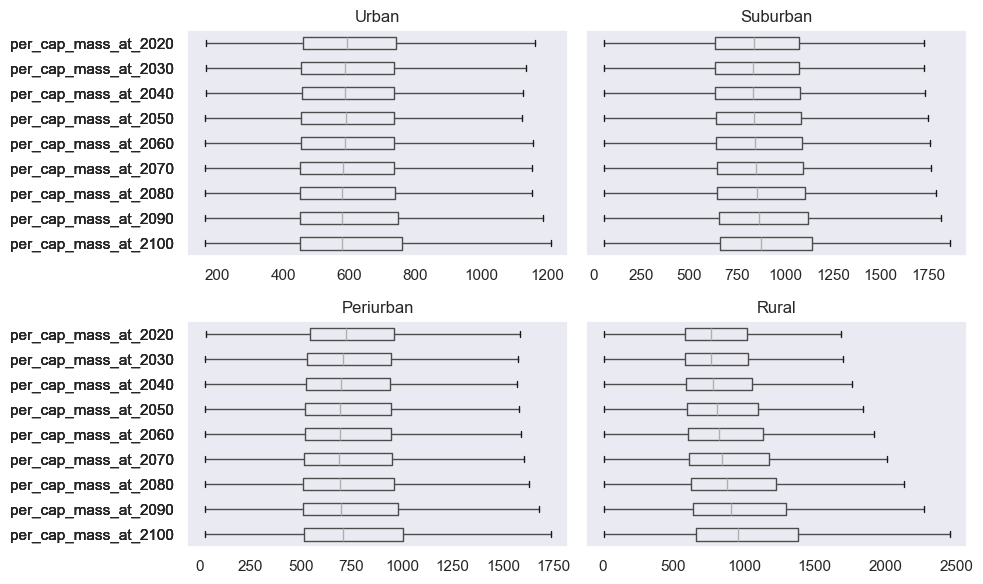

In [187]:
columns_boxplot = ['per_cap_mass_at_2100', 'per_cap_mass_at_2090','per_cap_mass_at_2080', 'per_cap_mass_at_2070','per_cap_mass_at_2060', 
                   'per_cap_mass_at_2050', 'per_cap_mass_at_2040','per_cap_mass_at_2030','per_cap_mass_at_2020']

# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharey=True)

# Boxplot for Value1 and Value2 in the first subplot
building_clean[building_clean['city type'] == 'urban'][columns_boxplot].boxplot(ax=axs[0, 0], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 0].set_title('Urban')
# # Boxplot for Value1 and Value3 in the second subplot
building_clean[building_clean['city type'] == 'suburban'][columns_boxplot].boxplot(ax=axs[0, 1], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 1].set_title('Suburban')
# # Boxplot for Value2 and Value3 in the third subplot
building_clean[building_clean['city type'] == 'periurban'][columns_boxplot].boxplot(ax=axs[1, 0], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 0].set_title('Periurban')
# # Boxplot for all three values in the fourth subplot
building_clean[building_clean['city type'] == 'rural'][columns_boxplot].boxplot(ax=axs[1, 1], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 1].set_title('Rural')
# Adjust layout
plt.tight_layout()

for ax in fig.axes:
    # ax.axis("off")
    ax.grid(False)

### download clean data

In [188]:
building_clean[['STATEFP','GEOID', 'NAMELSAD', 'surface_2020', 'surface_Res_2020', 'surface_nonRes_2020', 'volume_2020',
       'landAreaSqkm', 'percent_built_surface', ' !!Total:', 'HUs_occupied', 'HUs_vaccant','HUs_Total', 'YB_>=_2020', 'YB_2010_2019',
       'YB_2000_2009', 'YB_1980_1999', 'YB_1960_1979', 'YB_1940_1959','YB_<=_1939', 'Year_Built', 'Percent_Built', 'weighted_avg_age',
       'State', 'REGION', 'ua-to-place allocation factor_max', 'population_ua_min', 'population_ua_max', 'CensusPop_20', 'city type',
       'weighted_HU_density_sqmi', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100',
       'citytype_at_2030', 'citytype_at_2040', 'citytype_at_2050','citytype_at_2060', 'citytype_at_2070', 'citytype_at_2080',
       'citytype_at_2090', 'citytype_at_2100', 'ua_population_at_2030', 'ua_population_at_2040',
       'ua_population_at_2050', 'ua_population_at_2060',
       'ua_population_at_2070', 'ua_population_at_2080',
       'ua_population_at_2090', 'ua_population_at_2100', 'HU_density_sqmi_at_2030',
       'HU_density_sqmi_at_2040', 'HU_density_sqmi_at_2050',
       'HU_density_sqmi_at_2060', 'HU_density_sqmi_at_2070',
       'HU_density_sqmi_at_2080', 'HU_density_sqmi_at_2090',
       'HU_density_sqmi_at_2100']].to_csv(r'D:\Work\Box Sync\Quantify Infrastructure\output_csvs\output_city_type.csv')

In [189]:
building_clean.filter(regex = 'HU').columns

Index(['HUs_occupied', 'HUs_vaccant', 'HUs_Total', 'weighted_HU_density_sqmi',
       'HU_density_sqmile', 'avg_HU_size_Res_sqm', 'HU_density_sqmi_at_2030',
       'HU_density_sqmi_at_2040', 'HU_density_sqmi_at_2050',
       'HU_density_sqmi_at_2060', 'HU_density_sqmi_at_2070',
       'HU_density_sqmi_at_2080', 'HU_density_sqmi_at_2090',
       'HU_density_sqmi_at_2100', 'diff_HU', 'pop_per_HU'],
      dtype='object')

In [1]:
import pandas as pd
df_age = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\output_csvs\output_city_type.csv')

In [3]:
df_age.columns

Index(['Unnamed: 0', 'STATEFP', 'GEOID', 'NAMELSAD', 'surface_2020',
       'surface_Res_2020', 'surface_nonRes_2020', 'volume_2020',
       'landAreaSqkm', 'percent_built_surface', ' !!Total:', 'HUs_occupied',
       'HUs_vaccant', 'HUs_Total', 'YB_>=_2020', 'YB_2010_2019',
       'YB_2000_2009', 'YB_1980_1999', 'YB_1960_1979', 'YB_1940_1959',
       'YB_<=_1939', 'Year_Built', 'Percent_Built', 'weighted_avg_age',
       'State', 'REGION', 'ua-to-place allocation factor_max',
       'population_ua_min', 'population_ua_max', 'CensusPop_20', 'city type',
       'weighted_HU_density_sqmi', 'ssp22020', 'ssp22030', 'ssp22040',
       'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100',
       'citytype_at_2030', 'citytype_at_2040', 'citytype_at_2050',
       'citytype_at_2060', 'citytype_at_2070', 'citytype_at_2080',
       'citytype_at_2090', 'citytype_at_2100', 'ua_population_at_2030',
       'ua_population_at_2040', 'ua_population_at_2050',
       'ua_population_at_20

In [11]:
df_age.groupby(['city type','REGION'])[['weighted_avg_age']].mean().round(0).sort_values(by=['city type','weighted_avg_age'])

weighted_avg_age
city type REGION                     
periurban South                  41.0
          West                   43.0
          Midwest                50.0
          Northeast              58.0
rural     West                   48.0
          South                  49.0
          Midwest                60.0
          Northeast              63.0
suburban  South                  45.0
          West                   46.0
          Midwest                54.0
          Northeast              59.0
urban     South                  48.0
          West                   55.0
          Northeast              64.0
          Midwest                65.0

In [4]:
df_age.groupby(['REGION'])['weighted_avg_age'].describe().round(0)

,count,mean,std,min,25%,50%,75%,max
REGION,,,,,,,,
Midwest,9775.0,58.0,11.0,2.0,51.0,59.0,65.0,85.0
Northeast,4737.0,61.0,11.0,10.0,54.0,62.0,69.0,85.0
South,10275.0,46.0,12.0,9.0,38.0,46.0,54.0,85.0
West,5460.0,47.0,12.0,8.0,38.0,46.0,55.0,85.0
